### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelBinarizer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
!pip install pytorch-tabnet
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance

### Dataset Load

In [ ]:
df = pd.read_csv("/content/Attention.csv")
df

,Age,Age Range,Gender,Occupation,Highest Level of Education,How many hours do you sleep on average per night?,"How would you rate your sleep quality overall? ( 1 = Very Poor, 5 = Very Good)",On how many days in a typical week do you engage in atleast 30 minutes of moderate physical activity?,"How many hours per day do you spend on screens (phone, laptop, or TV)?","On a scale of 1–5, how often do you feel stressed in your daily life? (1 = Very Low, 5 = Very High)",...,13. I can become interested in a new topic very quickly when I need to.,14. It is easy for me to read or write while I’m also talking on the phone.,15. I have trouble carrying on two conversations at once.,16. I have a hard time coming up with new ideas quickly.,"17. After being interrupted or distracted, I can easily shift my attention back to what I was doing before.","18. When a distracting thought comes to mind, it is easy for me to shift my attention away from it.",19. It is easy for me to alternate between two different tasks.,20. It is hard for me to break from one way of thinking about something and look at it from another point of view.,Attention Score,Attention Class
0,25,25-31 years,Male,Student,Undergraduate,5-6 hours,4,1-3 days,6-7 hours,2,...,2,3,4,2,1,3,2,1,46,Medium
1,25,25-31 years,Male,Student,Higher Secondary,5-6 hours,3,3-5 days,Less than 5 hours,3,...,3,2,3,2,2,3,1,3,48,Medium
2,18,18-24 years,Male,Student,Undergraduate,7-8 hours,4,more than 5 days,8 hours or more,3,...,2,1,4,1,2,1,1,3,35,Low
3,21,18-24 years,Male,Student,Undergraduate,7-8 hours,3,1-3 days,6-7 hours,3,...,4,3,2,2,3,3,2,1,57,Medium
4,24,18-24 years,Female,Student,Undergraduate,7-8 hours,4,1-3 days,5-6 hours,4,...,4,2,2,2,4,4,4,3,60,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2127,31,25-31 years,Female,Working,Graduate,5-6 hours,2,Never,5-6 hours,2,...,4,3,2,2,3,2,3,2,50,Medium
2128,36,32-38 years,Male,Working,Graduate,5-6 hours,2,1-3 days,6-7 hours,2,...,1,2,3,2,1,2,1,2,45,Medium
2129,26,25-31 years,Female,Both,Graduate,Less than 5 hours,2,Never,8 hours or more,5,...,2,1,3,3,3,2,2,2,38,Low
2130,24,18-24 years,Male,Both,Undergraduate,5-6 hours,2,1-3 days,6-7 hours,3,...,2,3,2,3,2,2,3,3,47,Medium


In [ ]:
df.shape

(2132, 35)

### Drop Age Column

In [ ]:
df = df.drop(columns=["Age"])
df

,Age Range,Gender,Occupation,Highest Level of Education,How many hours do you sleep on average per night?,"How would you rate your sleep quality overall? ( 1 = Very Poor, 5 = Very Good)",On how many days in a typical week do you engage in atleast 30 minutes of moderate physical activity?,"How many hours per day do you spend on screens (phone, laptop, or TV)?","On a scale of 1–5, how often do you feel stressed in your daily life? (1 = Very Low, 5 = Very High)","How many cups of caffeinated drinks (coffee, tea, energy drinks) do you consume per day?",...,13. I can become interested in a new topic very quickly when I need to.,14. It is easy for me to read or write while I’m also talking on the phone.,15. I have trouble carrying on two conversations at once.,16. I have a hard time coming up with new ideas quickly.,"17. After being interrupted or distracted, I can easily shift my attention back to what I was doing before.","18. When a distracting thought comes to mind, it is easy for me to shift my attention away from it.",19. It is easy for me to alternate between two different tasks.,20. It is hard for me to break from one way of thinking about something and look at it from another point of view.,Attention Score,Attention Class
0,25-31 years,Male,Student,Undergraduate,5-6 hours,4,1-3 days,6-7 hours,2,0 cup,...,2,3,4,2,1,3,2,1,46,Medium
1,25-31 years,Male,Student,Higher Secondary,5-6 hours,3,3-5 days,Less than 5 hours,3,1-2 cups,...,3,2,3,2,2,3,1,3,48,Medium
2,18-24 years,Male,Student,Undergraduate,7-8 hours,4,more than 5 days,8 hours or more,3,0 cup,...,2,1,4,1,2,1,1,3,35,Low
3,18-24 years,Male,Student,Undergraduate,7-8 hours,3,1-3 days,6-7 hours,3,0 cup,...,4,3,2,2,3,3,2,1,57,Medium
4,18-24 years,Female,Student,Undergraduate,7-8 hours,4,1-3 days,5-6 hours,4,0 cup,...,4,2,2,2,4,4,4,3,60,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2127,25-31 years,Female,Working,Graduate,5-6 hours,2,Never,5-6 hours,2,1-2 cups,...,4,3,2,2,3,2,3,2,50,Medium
2128,32-38 years,Male,Working,Graduate,5-6 hours,2,1-3 days,6-7 hours,2,1-2 cups,...,1,2,3,2,1,2,1,2,45,Medium
2129,25-31 years,Female,Both,Graduate,Less than 5 hours,2,Never,8 hours or more,5,2-3 cups,...,2,1,3,3,3,2,2,2,38,Low
2130,18-24 years,Male,Both,Undergraduate,5-6 hours,2,1-3 days,6-7 hours,3,1-2 cups,...,2,3,2,3,2,2,3,3,47,Medium


### Rename Columns

In [ ]:
rename_dict = {
    "Age": "Age",
    "Age Range": "Age_Range",
    "Gender": "Gender",
    "Occupation": "Occupation",
    "Highest Level of Education": "Education_Level",
    "How many hours do you sleep on average per night?": "Sleep_Hours",
    "How would you rate your sleep quality overall? ( 1 = Very Poor, 5 = Very Good)": "Sleep_Quality",
    "On how many days in a typical week do you engage in atleast 30 minutes of moderate physical activity?": "Physical_Activity",
    "How many hours per day do you spend on screens (phone, laptop, or TV)?": "Screen_Time",
    "On a scale of 1–5, how often do you feel stressed in your daily life? (1 = Very Low, 5 = Very High)": "Stress_Level",
    "How many cups of caffeinated drinks (coffee, tea, energy drinks) do you consume per day?": "Caffeine_Intake",
    "Do you usually multitask while studying or working?": "Multitasking",
    "Do you read or engage with long-form content (books, long articles, podcasts) regularly?": "Long_Form_Content",
    "Attention Score": "Attention_Score",
    "Attention Class": "Attention_Class"
}

df = df.rename(columns=rename_dict)

In [ ]:
question_cols = [col for col in df.columns if col.split(".")[0].isdigit()]
question_rename = {col: f"Attn_Q{i+1}" for i, col in enumerate(question_cols)}
df = df.rename(columns=question_rename)

In [ ]:
print(df.columns.tolist())

['Age_Range', 'Gender', 'Occupation', 'Education_Level', 'Sleep_Hours', 'Sleep_Quality', 'Physical_Activity', 'Screen_Time', 'Stress_Level', 'Caffeine_Intake', 'Multitasking', 'Long_Form_Content', 'Attn_Q1', 'Attn_Q2', 'Attn_Q3', 'Attn_Q4', 'Attn_Q5', 'Attn_Q6', 'Attn_Q7', 'Attn_Q8', 'Attn_Q9', 'Attn_Q10', 'Attn_Q11', 'Attn_Q12', 'Attn_Q13', 'Attn_Q14', 'Attn_Q15', 'Attn_Q16', 'Attn_Q17', 'Attn_Q18', 'Attn_Q19', 'Attn_Q20', 'Attention_Score', 'Attention_Class']


### Check Missing Values

In [ ]:
# Check missing values in each column
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
Age_Range            0
Gender               0
Occupation           0
Education_Level      0
Sleep_Hours          0
Sleep_Quality        0
Physical_Activity    0
Screen_Time          0
Stress_Level         0
Caffeine_Intake      0
Multitasking         0
Long_Form_Content    0
Attn_Q1              0
Attn_Q2              0
Attn_Q3              0
Attn_Q4              0
Attn_Q5              0
Attn_Q6              0
Attn_Q7              0
Attn_Q8              0
Attn_Q9              0
Attn_Q10             0
Attn_Q11             0
Attn_Q12             0
Attn_Q13             0
Attn_Q14             0
Attn_Q15             0
Attn_Q16             0
Attn_Q17             0
Attn_Q18             0
Attn_Q19             0
Attn_Q20             0
Attention_Score      0
Attention_Class      0
dtype: int64


### Check Duplicate Rows

In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
df.describe()

,Sleep_Quality,Stress_Level,Attn_Q1,Attn_Q2,Attn_Q3,Attn_Q4,Attn_Q5,Attn_Q6,Attn_Q7,Attn_Q8,...,Attn_Q12,Attn_Q13,Attn_Q14,Attn_Q15,Attn_Q16,Attn_Q17,Attn_Q18,Attn_Q19,Attn_Q20,Attention_Score
count,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,...,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000
mean,3.251876,3.214353,2.904784,2.166041,2.398218,1.942308,2.334428,2.654784,2.254690,2.346154,...,2.571764,2.606004,1.904315,2.824109,2.486398,2.813790,2.308161,2.586304,2.258443,49.466229
std,0.997355,0.964660,0.909740,0.863576,0.790284,0.872948,0.829578,0.843425,0.798492,0.984283,...,0.930232,0.789134,0.862831,0.863527,0.808393,0.893449,0.860123,0.800375,0.848052,8.733839
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,25.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,45.000000
50%,3.000000,3.000000,3.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,...,3.000000,3.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,2.000000,49.000000
75%,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,54.000000
max,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,75.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2132 entries, 0 to 2131
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age_Range          2132 non-null   object
 1   Gender             2132 non-null   object
 2   Occupation         2132 non-null   object
 3   Education_Level    2132 non-null   object
 4   Sleep_Hours        2132 non-null   object
 5   Sleep_Quality      2132 non-null   int64 
 6   Physical_Activity  2132 non-null   object
 7   Screen_Time        2132 non-null   object
 8   Stress_Level       2132 non-null   int64 
 9   Caffeine_Intake    2132 non-null   object
 10  Multitasking       2132 non-null   object
 11  Long_Form_Content  2132 non-null   object
 12  Attn_Q1            2132 non-null   int64 
 13  Attn_Q2            2132 non-null   int64 
 14  Attn_Q3            2132 non-null   int64 
 15  Attn_Q4            2132 non-null   int64 
 16  Attn_Q5            2132 non-null   int64 


In [ ]:
df.describe(include='object')

,Age_Range,Gender,Occupation,Education_Level,Sleep_Hours,Physical_Activity,Screen_Time,Caffeine_Intake,Multitasking,Long_Form_Content,Attention_Class
count,2132,2132,2132,2132,2132,2132,2132,2132,2132,2132,2132
unique,5,2,4,4,4,4,4,4,4,4,3
top,18-24 years,Male,Student,Undergraduate,5-6 hours,1-3 days,5-6 hours,0 cup,Sometimes,Sometimes,Medium
freq,1077,1213,1277,963,1004,840,891,793,885,1130,1585


### Ordinal Encoding

In [ ]:
# Columns to encode
ordinal_cols = [
    "Age_Range",
    "Education_Level",
    "Sleep_Hours",
    "Physical_Activity",
    "Screen_Time",
    "Caffeine_Intake",
    "Multitasking",
    "Long_Form_Content"
]

# Ordered categories based on your dataset
ordinal_categories = [
    ["Below 18 years", "18-24 years", "25-31 years", "32-38 years", "Above 38 years"],   # Age_Range
    ["Higher Secondary", "Undergraduate", "Graduate", "Postgraduate", "Other"],  # Education_Level
    ["Less than 5 hours", "5-6 hours", "7-8 hours", "9 hours or more"],     # SleepHours
    ["Never", "1-3 days", "3-5 days", "more than 5 days"],                  # PhysicalActivity
    ["Less than 5 hours", "5-6 hours", "6-7 hours", "8 hours or more"],   # ScreenTime
    ["0 cup", "1-2 cups", "2-3 cups", "more than 3 cups"],       # CaffeineIntake
    ["Rarely", "Sometimes", "Often", "Always"],     # Multitasking
    ["Never", "Rarely", "Sometimes", "Often",]     # LongFormReading
]

# Apply Ordinal Encoder
encoder = OrdinalEncoder(categories=ordinal_categories)

df[ordinal_cols] = encoder.fit_transform(df[ordinal_cols])

### OneHot Encoding

In [ ]:
df = pd.get_dummies(df, columns=["Gender", "Occupation"])
print("Updated shape:", df.shape)
df

Updated shape: (2132, 38)


,Age_Range,Education_Level,Sleep_Hours,Sleep_Quality,Physical_Activity,Screen_Time,Stress_Level,Caffeine_Intake,Multitasking,Long_Form_Content,...,Attn_Q19,Attn_Q20,Attention_Score,Attention_Class,Gender_Female,Gender_Male,Occupation_Both,Occupation_Other,Occupation_Student,Occupation_Working
0,2.0,1.0,1.0,4,1.0,2.0,2,0.0,2.0,2.0,...,2,1,46,Medium,False,True,False,False,True,False
1,2.0,0.0,1.0,3,2.0,0.0,3,1.0,3.0,3.0,...,1,3,48,Medium,False,True,False,False,True,False
2,1.0,1.0,2.0,4,3.0,3.0,3,0.0,2.0,2.0,...,1,3,35,Low,False,True,False,False,True,False
3,1.0,1.0,2.0,3,1.0,2.0,3,0.0,0.0,2.0,...,2,1,57,Medium,False,True,False,False,True,False
4,1.0,1.0,2.0,4,1.0,1.0,4,0.0,1.0,2.0,...,4,3,60,High,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2127,2.0,2.0,1.0,2,0.0,1.0,2,1.0,2.0,1.0,...,3,2,50,Medium,True,False,False,False,False,True
2128,3.0,2.0,1.0,2,1.0,2.0,2,1.0,2.0,1.0,...,1,2,45,Medium,False,True,False,False,False,True
2129,2.0,2.0,0.0,2,0.0,3.0,5,2.0,1.0,1.0,...,2,2,38,Low,True,False,True,False,False,False
2130,1.0,1.0,1.0,2,1.0,2.0,3,1.0,2.0,2.0,...,3,3,47,Medium,False,True,True,False,False,False


### Drop Attention Score Column

In [ ]:
df = df.drop(columns=["Attention_Score"])

### Target Class Label Encoding

In [ ]:
le = LabelEncoder()

df["Attention_Class"] = le.fit_transform(df["Attention_Class"])

print(le.classes_)

['High' 'Low' 'Medium']


### Target and Features Split

In [ ]:
X = df.drop(columns=["Attention_Class"])
y = df["Attention_Class"]

### Train Test Split

In [ ]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% test data
    random_state=42,    # reproducibility
    stratify=y          # keep class distribution balanced
)

# Check shapes
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (1705, 36)
Testing Features: (427, 36)
Training Target: (1705,)
Testing Target: (427,)


### Outlier Detection by IQR method

In [ ]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers, lower_bound, upper_bound


# Only use numeric feature columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = []

for col in numeric_cols:
    outliers, low, high = detect_outliers_iqr(X, col)
    outlier_summary.append([col, len(outliers), low, high])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Outlier Count", "Lower Bound", "Upper Bound"]
)

print(outlier_df)

              Feature  Outlier Count  Lower Bound  Upper Bound
0           Age_Range            153         -0.5          3.5
1     Education_Level              0         -0.5          3.5
2         Sleep_Hours              0         -0.5          3.5
3       Sleep_Quality              0         -1.0          7.0
4   Physical_Activity             93         -1.5          2.5
5         Screen_Time              0         -0.5          3.5
6        Stress_Level              0         -1.0          7.0
7     Caffeine_Intake              0         -3.0          5.0
8        Multitasking              0         -0.5          3.5
9   Long_Form_Content              0         -0.5          3.5
10            Attn_Q1              0         -1.0          7.0
11            Attn_Q2              0          0.5          4.5
12            Attn_Q3              0          0.5          4.5
13            Attn_Q4              0         -2.0          6.0
14            Attn_Q5              0          0.5      

### Check Continuous Values

In [ ]:
def is_continuous(series, threshold=15):
    unique_vals = series.nunique()
    total_vals = len(series)
    ratio = unique_vals / total_vals

    return unique_vals >= threshold and ratio > 0.01

for col in df.select_dtypes(include=["int64","float64"]).columns:
    print(col, "Continuous?" , is_continuous(df[col]))

Age_Range Continuous? False
Education_Level Continuous? False
Sleep_Hours Continuous? False
Sleep_Quality Continuous? False
Physical_Activity Continuous? False
Screen_Time Continuous? False
Stress_Level Continuous? False
Caffeine_Intake Continuous? False
Multitasking Continuous? False
Long_Form_Content Continuous? False
Attn_Q1 Continuous? False
Attn_Q2 Continuous? False
Attn_Q3 Continuous? False
Attn_Q4 Continuous? False
Attn_Q5 Continuous? False
Attn_Q6 Continuous? False
Attn_Q7 Continuous? False
Attn_Q8 Continuous? False
Attn_Q9 Continuous? False
Attn_Q10 Continuous? False
Attn_Q11 Continuous? False
Attn_Q12 Continuous? False
Attn_Q13 Continuous? False
Attn_Q14 Continuous? False
Attn_Q15 Continuous? False
Attn_Q16 Continuous? False
Attn_Q17 Continuous? False
Attn_Q18 Continuous? False
Attn_Q19 Continuous? False
Attn_Q20 Continuous? False
Attention_Class Continuous? False


### Handle Class imbalance by SMOTE

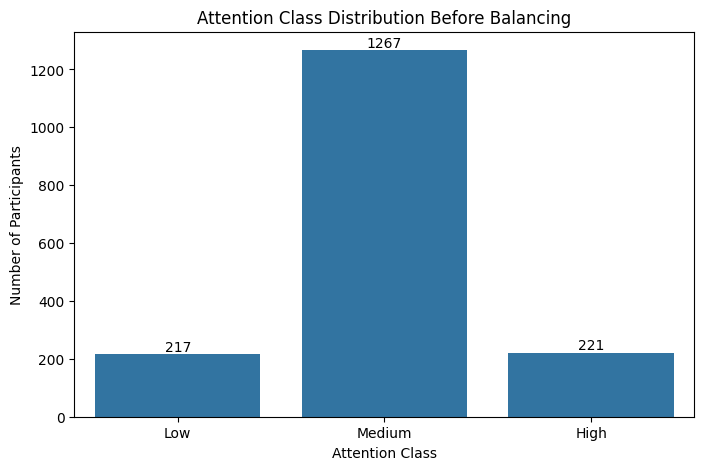

In [ ]:
y_train_labels = pd.Series(le.inverse_transform(y_train), name="Attention_Class")

plt.figure(figsize=(8,5))

ax = sns.countplot(x=y_train_labels, order=["Low","Medium","High"])

# Add count labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Attention Class Distribution Before Balancing")
plt.xlabel("Attention Class")
plt.ylabel("Number of Participants")

plt.show()

In [ ]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
print("Before SMOTE:")
print(pd.Series(le.inverse_transform(y_train)).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(le.inverse_transform(y_train_resampled)).value_counts())

Before SMOTE:
Medium    1267
High       221
Low        217
Name: count, dtype: int64

After SMOTE:
Low       1267
Medium    1267
High      1267
Name: count, dtype: int64


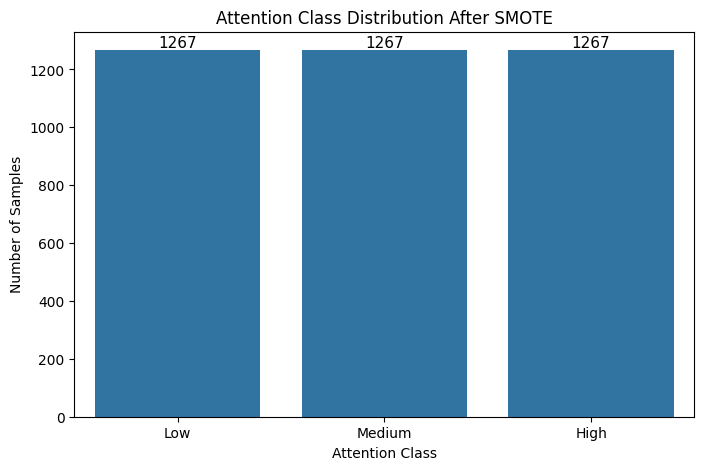

In [ ]:
# Convert encoded labels back to original class names
y_resampled_labels = pd.Series(
    le.inverse_transform(y_train_resampled),
    name="Attention_Class"
)

# Plot bar chart
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x=y_resampled_labels,
    order=["Low","Medium","High"]
)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Attention Class Distribution After SMOTE")
plt.xlabel("Attention Class")
plt.ylabel("Number of Samples")

plt.show()

### Feature Selection by Anova f-score

In [ ]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_resampled, y_train_resampled)

SelectKBest(k='all')

In [ ]:
anova_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "F_Score": selector.scores_
})

anova_scores = anova_scores.sort_values(by="F_Score", ascending=False)

print(anova_scores)

               Feature      F_Score
19            Attn_Q10  2567.653838
28            Attn_Q19  2445.400082
20            Attn_Q11  2443.528060
27            Attn_Q18  2318.914014
29            Attn_Q20  2195.565333
5          Screen_Time  2154.245039
16             Attn_Q7  2151.146850
12             Attn_Q3  2048.368311
11             Attn_Q2  2026.670667
21            Attn_Q12  1941.895199
17             Attn_Q8  1886.085943
4    Physical_Activity  1829.224020
3        Sleep_Quality  1812.312255
15             Attn_Q6  1799.802769
25            Attn_Q16  1749.479607
18             Attn_Q9  1724.509032
26            Attn_Q17  1699.292567
14             Attn_Q5  1692.130035
22            Attn_Q13  1297.839253
9    Long_Form_Content  1283.327872
2          Sleep_Hours  1222.128076
10             Attn_Q1  1074.961379
13             Attn_Q4   929.281905
23            Attn_Q14   774.778429
6         Stress_Level   748.854766
24            Attn_Q15   689.312887
35  Occupation_Working   686

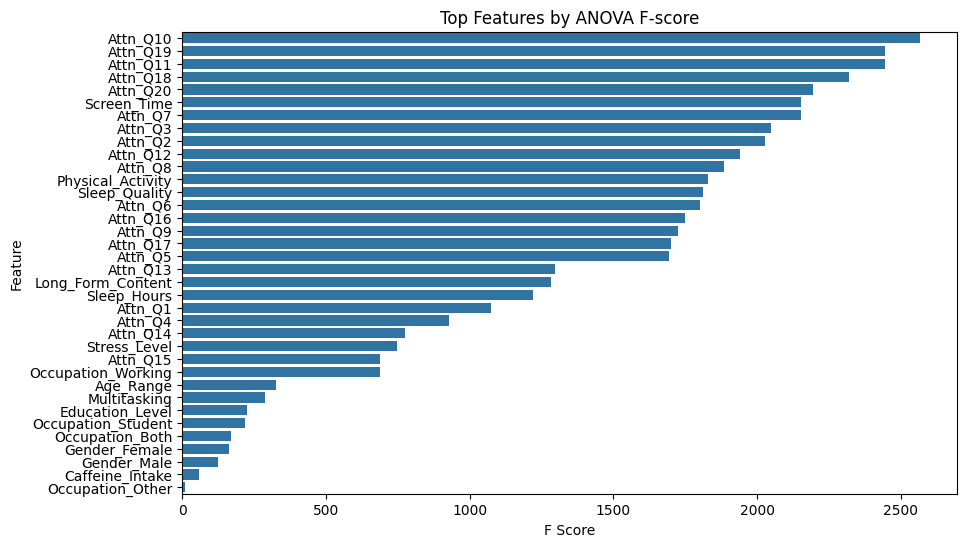

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="F_Score",
    y="Feature",
    data=anova_scores
)

plt.title("Top Features by ANOVA F-score")
plt.xlabel("F Score")
plt.ylabel("Feature")

plt.show()

In [ ]:
selector = SelectKBest(score_func=f_classif, k=25)

X_train_selected = selector.fit_transform(X_train_resampled, y_train_resampled)
X_test_selected = selector.transform(X_test)

### Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled  = scaler.transform(X_test_selected)

# Model Training

### Random Forest

In [ ]:
rf = RandomForestClassifier(
   n_estimators=500,
   random_state=42,
   n_jobs=-1,
   max_depth=5,
   min_samples_split=25,
   min_samples_leaf=20,
   max_features="sqrt",
   bootstrap=True)
rf.fit(X_train_selected_scaled, y_train_resampled)

y_train_pred_rf = rf.predict(X_train_selected_scaled)
y_test_pred_rf = rf.predict(X_test_selected_scaled)

train_acc = accuracy_score(y_train_resampled, y_train_pred_rf)
test_acc = accuracy_score(y_test, y_test_pred_rf)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

Training Accuracy: 0.9584319915811629
Testing Accuracy : 0.9344262295081968


In [ ]:
print(classification_report(y_test, y_test_pred_rf, target_names=["Low", "Medium", "High"]))

              precision    recall  f1-score   support

         Low       0.87      0.87      0.87        55
      Medium       0.87      0.87      0.87        54
        High       0.96      0.96      0.96       318

    accuracy                           0.93       427
   macro avg       0.90      0.90      0.90       427
weighted avg       0.93      0.93      0.93       427



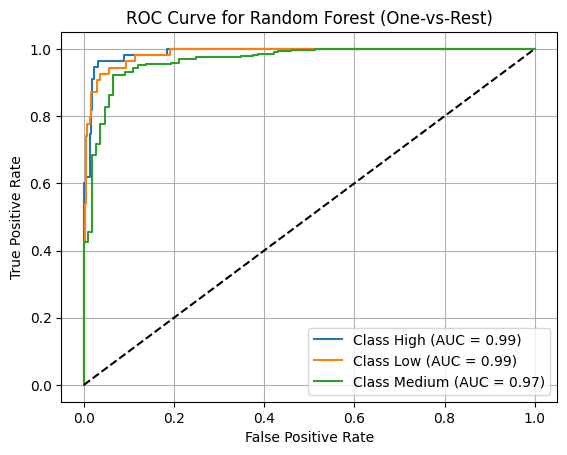

In [ ]:
from sklearn.preprocessing import LabelBinarizer

def plot_multiclass_roc(clf, X_test, y_test, n_classes, class_labels):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)
    y_score = clf.predict_proba(X_test)

    # Plot ROC curve for each class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_score = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], 'k--') # random guessing line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Random Forest (One-vs-Rest)')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

class_labels = le.classes_
plot_multiclass_roc(rf, X_test_selected_scaled, y_test, n_classes=len(class_labels), class_labels=class_labels)

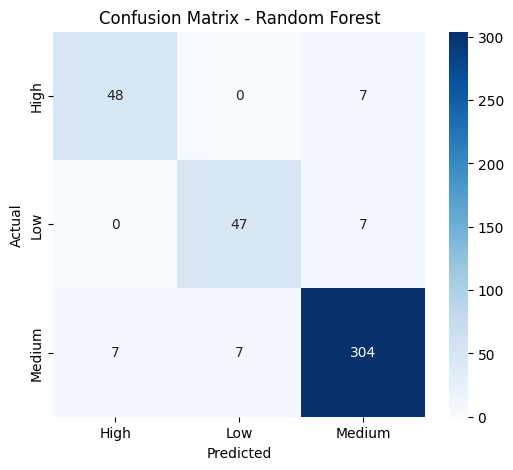

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### XGBoost

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.2,
    colsample_bytree=0.2,
    min_child_weight=3,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

xgb.fit(X_train_selected_scaled, y_train_resampled)

y_train_pred_xgb = xgb.predict(X_train_selected_scaled)
y_test_pred_xgb = xgb.predict(X_test_selected_scaled)

train_acc = accuracy_score(y_train_resampled, y_train_pred_xgb)
test_acc = accuracy_score(y_test, y_test_pred_xgb)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

Training Accuracy: 0.976848197842673
Testing Accuracy : 0.955503512880562


In [ ]:
print(classification_report(y_test, y_test_pred_xgb, target_names=["Low", "Medium", "High"]))

              precision    recall  f1-score   support

         Low       0.88      0.93      0.90        55
      Medium       0.93      0.93      0.93        54
        High       0.97      0.97      0.97       318

    accuracy                           0.96       427
   macro avg       0.93      0.94      0.93       427
weighted avg       0.96      0.96      0.96       427



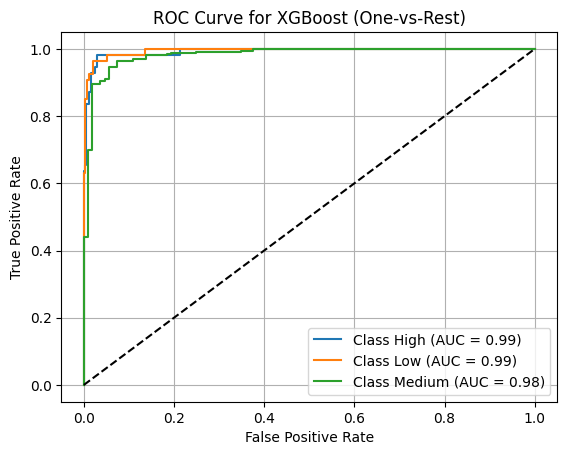

In [ ]:
def plot_multiclass_roc(clf, X_test, y_test, n_classes, class_labels):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)
    y_score = clf.predict_proba(X_test)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_score = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for XGBoost (One-vs-Rest)')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

class_labels = le.classes_
plot_multiclass_roc(xgb, X_test_selected_scaled, y_test, n_classes=len(class_labels), class_labels=class_labels)

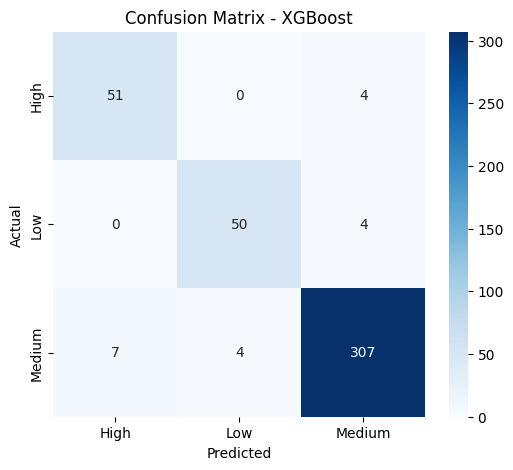

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

### Extra Trees

In [ ]:
et = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

et.fit(X_train_selected_scaled, y_train_resampled)

y_train_pred_et = et.predict(X_train_selected_scaled)
y_test_pred_et = et.predict(X_test_selected_scaled)

train_acc = accuracy_score(y_train_resampled, y_train_pred_et)
test_acc = accuracy_score(y_test, y_test_pred_et)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

Training Accuracy: 0.986056300973428
Testing Accuracy : 0.9625292740046838


In [ ]:
print(classification_report(y_test, y_test_pred_et, target_names=["Low", "Medium", "High"]))

              precision    recall  f1-score   support

         Low       0.90      0.95      0.92        55
      Medium       0.96      0.91      0.93        54
        High       0.97      0.97      0.97       318

    accuracy                           0.96       427
   macro avg       0.94      0.94      0.94       427
weighted avg       0.96      0.96      0.96       427



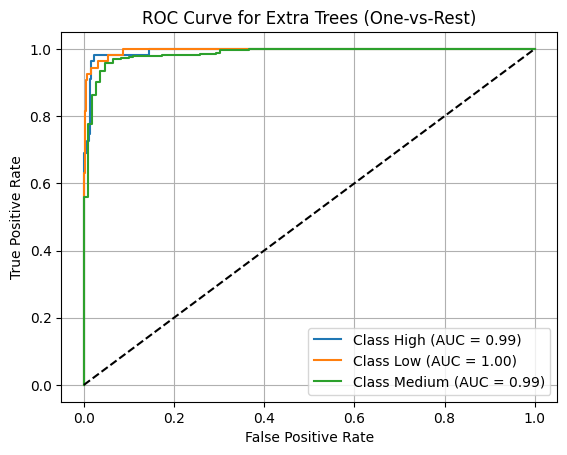

In [ ]:
def plot_multiclass_roc(clf, X_test, y_test, n_classes, class_labels):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)
    y_score = clf.predict_proba(X_test)

    # Plot ROC curve for each class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_score = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Extra Trees (One-vs-Rest)')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

class_labels = le.classes_
plot_multiclass_roc(et, X_test_selected_scaled, y_test, n_classes=len(class_labels), class_labels=class_labels)

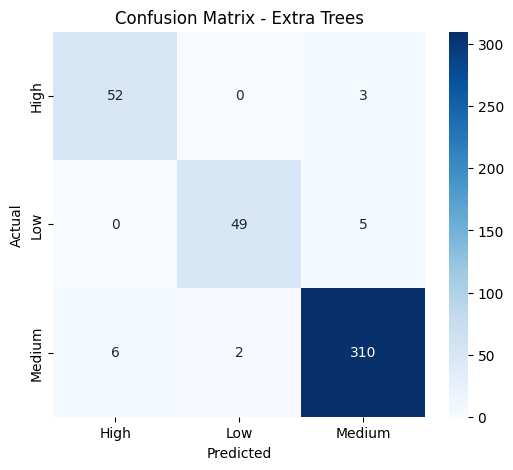

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_et)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Extra Trees")
plt.show()

### Logistic Regression

In [ ]:
log_reg = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    multi_class="multinomial",
    C=1.0,
    random_state=42
)

log_reg.fit(X_train_selected_scaled, y_train_resampled)

y_train_pred_lr = log_reg.predict(X_train_selected_scaled)
y_test_pred_lr = log_reg.predict(X_test_selected_scaled)

train_acc_lr = accuracy_score(y_train_resampled, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)

print("Training Accuracy:", train_acc_lr)
print("Testing Accuracy :", test_acc_lr)

Training Accuracy: 0.994475138121547
Testing Accuracy : 0.9695550351288056


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
print(classification_report(y_test, y_test_pred_lr, target_names=["Low", "Medium", "High"]))

              precision    recall  f1-score   support

         Low       0.90      0.98      0.94        55
      Medium       0.91      0.98      0.95        54
        High       0.99      0.97      0.98       318

    accuracy                           0.97       427
   macro avg       0.94      0.98      0.95       427
weighted avg       0.97      0.97      0.97       427



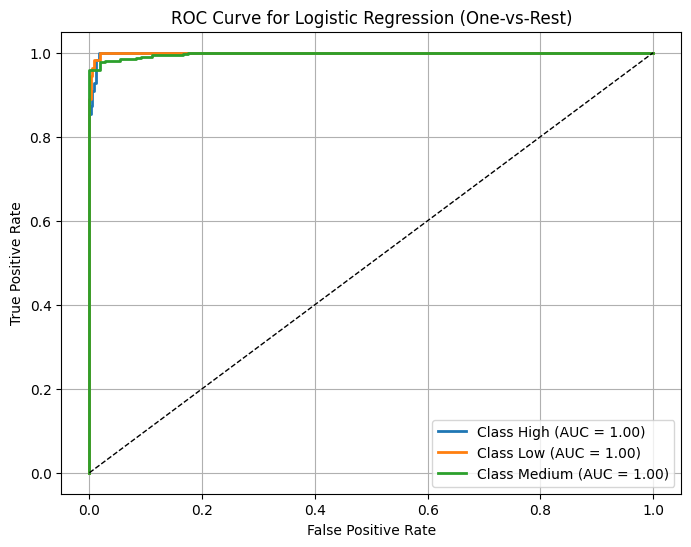

In [ ]:
def plot_multiclass_roc(clf, X_test, y_test, class_labels, model_name="Classifier"):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)

    if y_test_bin.ndim == 1:
        y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

    y_score = clf.predict_proba(X_test)

    plt.figure(figsize=(8, 6))

    n_classes = len(class_labels)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_score = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, linewidth=2,
                 label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for {model_name} (One-vs-Rest)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

class_labels = le.classes_

plot_multiclass_roc(
    log_reg,
    X_test=X_test_selected_scaled,
    y_test=y_test,
    class_labels=class_labels,
    model_name="Logistic Regression"
)

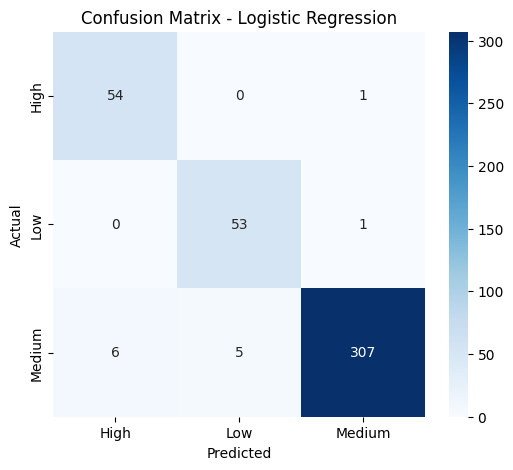

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### SVM

In [ ]:
svm = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_train_selected_scaled, y_train_resampled)

y_train_pred_svm = svm.predict(X_train_selected_scaled)
y_test_pred_svm = svm.predict(X_test_selected_scaled)

train_acc_svm = accuracy_score(y_train_resampled, y_train_pred_svm)
test_acc_svm = accuracy_score(y_test, y_test_pred_svm)

print("Training Accuracy:", train_acc_svm)
print("Testing Accuracy :", test_acc_svm)

Training Accuracy: 0.9950013154433044
Testing Accuracy : 0.9695550351288056


In [ ]:
print(classification_report(y_test, y_test_pred_svm, target_names=["Low", "Medium", "High"]))

              precision    recall  f1-score   support

         Low       0.91      0.96      0.94        55
      Medium       0.94      0.94      0.94        54
        High       0.98      0.97      0.98       318

    accuracy                           0.97       427
   macro avg       0.95      0.96      0.95       427
weighted avg       0.97      0.97      0.97       427



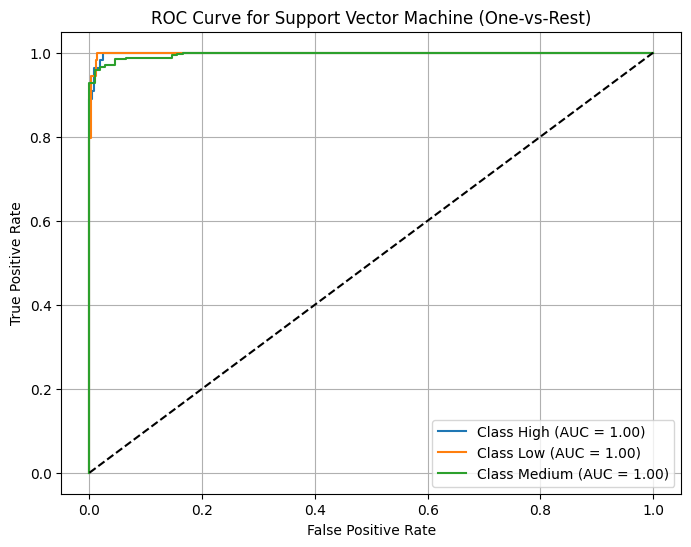

In [ ]:
def plot_multiclass_roc(clf, X_test, y_test, n_classes, class_labels, model_name="Classifier"):

    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)

    if y_test_bin.ndim == 1:
        y_test_bin = np.column_stack((1 - y_test_bin, y_test_bin))

    y_score = clf.predict_proba(X_test)

    plt.figure(figsize=(8,6))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_score = roc_auc_score(y_test_bin[:, i], y_score[:, i])

        plt.plot(
            fpr,
            tpr,
            label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})'
        )

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for {model_name} (One-vs-Rest)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

    class_labels = le.classes_

plot_multiclass_roc(
    svm,
    X_test_selected_scaled,
    y_test,
    n_classes=len(class_labels),
    class_labels=class_labels,
    model_name="Support Vector Machine"
)

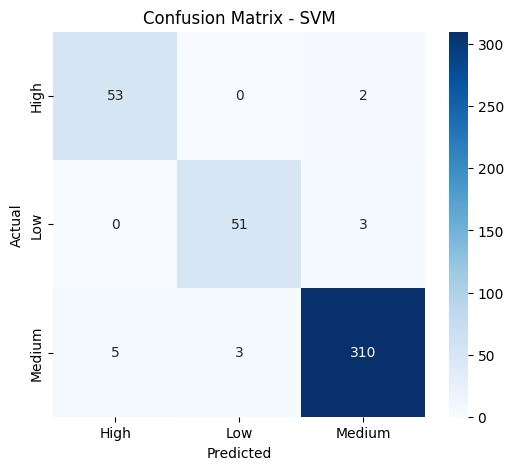

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

### MLP

In [ ]:
mlp = keras.Sequential([
    layers.Input(shape=(X_train_selected_scaled.shape[1],)),   # Input layer

    layers.Dense(128, activation='relu'),             # Hidden Layer 1
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),              # Hidden Layer 2
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),              # Hidden Layer 3
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')             # Output Layer (3 Classes)
])

mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = mlp.fit(
    X_train_selected_scaled,
    y_train_resampled,
    epochs=20,
    batch_size=42,
    validation_split=0.2,
    verbose=1
)

_, train_acc = mlp.evaluate(X_train_selected_scaled, y_train_resampled, verbose=0)
_, test_acc  = mlp.evaluate(X_test_selected_scaled, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7428 - loss: 0.5790 - val_accuracy: 0.9553 - val_loss: 0.2017
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9135 - loss: 0.2461 - val_accuracy: 0.9790 - val_loss: 0.0776
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9332 - loss: 0.1894 - val_accuracy: 0.9882 - val_loss: 0.0688
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9382 - loss: 0.1640 - val_accuracy: 0.9934 - val_loss: 0.0385
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9493 - loss: 0.1453 - val_accuracy: 0.9934 - val_loss: 0.0335
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9553 - loss: 0.1253 - val_accuracy: 0.9934 - val_loss: 0.0225
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9602 - loss: 0.1078 - val_accuracy: 0.9947 - val_loss: 0.0246
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9664 - loss: 0.0969 - val_accuracy: 0.9934 - val_l

In [ ]:
y_pred_prob = mlp.predict(X_test_selected_scaled)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Classification Report (MLP):")
print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Classification Report (MLP):
              precision    recall  f1-score   support

         Low       0.88      0.96      0.92        55
      Medium       0.91      0.94      0.93        54
        High       0.98      0.96      0.97       318

    accuracy                           0.96       427
   macro avg       0.93      0.96      0.94       427
weighted avg       0.96      0.96      0.96       427



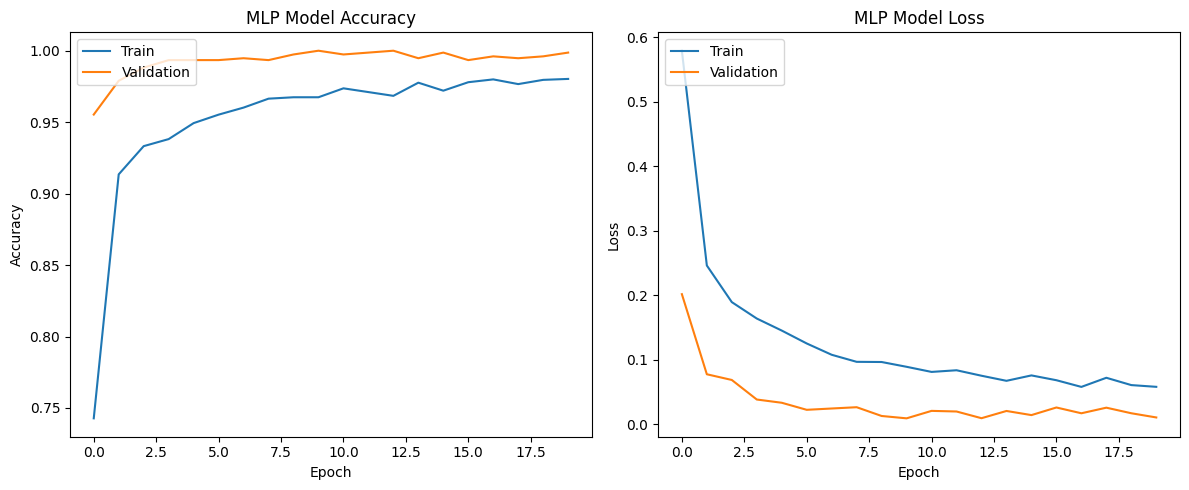

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('MLP Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('MLP Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


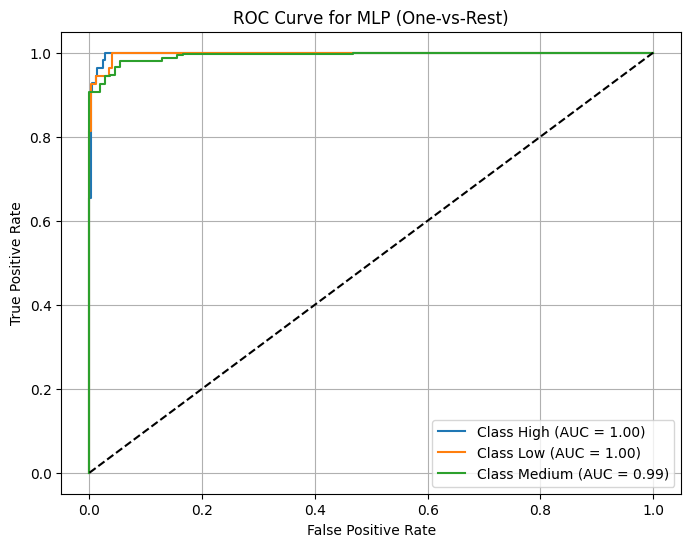

In [ ]:
def plot_multiclass_roc(clf_model, X_test, y_test, n_classes, class_labels, title_prefix):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)

    y_score = clf_model.predict(X_test)

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        if np.any(y_test_bin[:, i] == 1):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            auc_score = roc_auc_score(y_test_bin[:, i], y_score[:, i])
            plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})')
        else:
            print(f"Warning: No positive samples for Class {class_labels[i]} in test set. Skipping ROC for this class.")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {title_prefix} (One-vs-Rest)')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

class_labels = le.classes_
plot_multiclass_roc(mlp, X_test_selected_scaled, y_test, n_classes=len(class_labels), class_labels=class_labels, title_prefix="MLP")

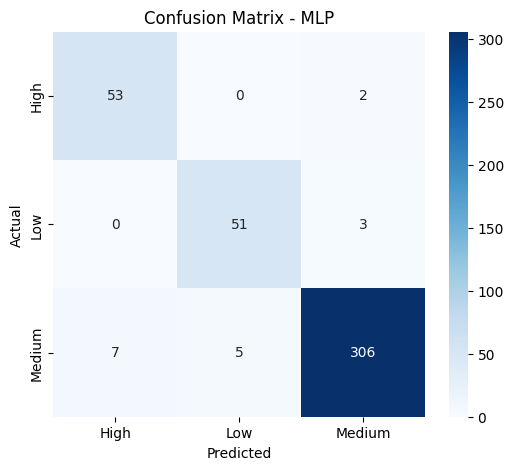

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MLP")
plt.show()

### ANN

In [ ]:
ann = keras.Sequential([
    layers.Input(shape=(X_train_selected_scaled.shape[1],)),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(3, activation="softmax")
])

ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

history = ann.fit(
    X_train_selected_scaled,
    y_train_resampled,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

_, train_acc = ann.evaluate(X_train_selected_scaled, y_train_resampled, verbose=0)
_, test_acc  = ann.evaluate(X_test_selected_scaled, y_test, verbose=0)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8461 - loss: 0.4074 - val_accuracy: 0.9514 - val_loss: 0.1733 - learning_rate: 0.0010
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9398 - loss: 0.1581 - val_accuracy: 0.9527 - val_loss: 0.1156 - learning_rate: 0.0010
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9414 - loss: 0.1625 - val_accuracy: 0.9961 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9553 - loss: 0.1282 - val_accuracy: 0.9947 - val_loss: 0.0239 - learning_rate: 0.0010
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9609 - loss: 0.1270 - val_accuracy: 0.9974 - val_loss: 0.0162 - learning_rate: 0.0010
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9632 - loss: 0.1009 - val_accuracy: 0.9921 - val_loss: 0.0289 - learning_rate: 0.0010
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9615 - loss: 0.1053 - val_accura

In [ ]:
y_pred_prob = ann.predict(X_test_selected_scaled)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Classification Report (ANN):")
print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Classification Report (ANN):
              precision    recall  f1-score   support

         Low       0.92      0.98      0.95        55
      Medium       0.93      1.00      0.96        54
        High       1.00      0.97      0.98       318

    accuracy                           0.98       427
   macro avg       0.95      0.98      0.97       427
weighted avg       0.98      0.98      0.98       427



14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


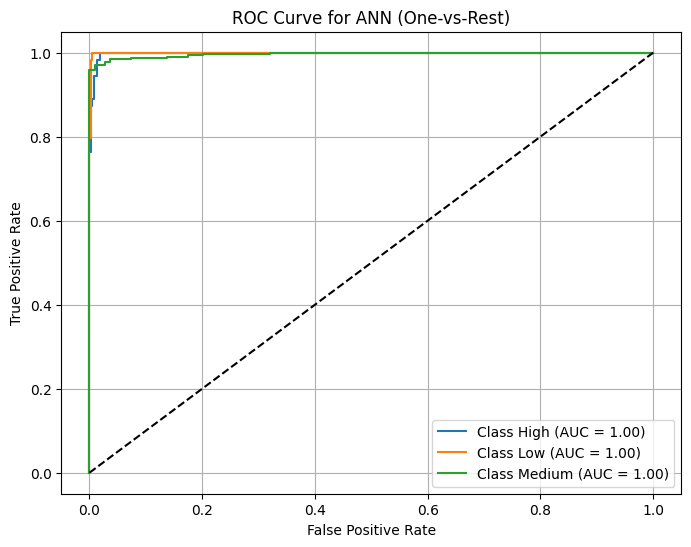

In [ ]:
def plot_multiclass_roc(clf_model, X_test, y_test, n_classes, class_labels, title_prefix):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)

    y_score = clf_model.predict(X_test)

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        if np.any(y_test_bin[:, i] == 1):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            auc_score = roc_auc_score(y_test_bin[:, i], y_score[:, i])
            plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})')
        else:
            print(f"Warning: No positive samples for Class {class_labels[i]} in test set. Skipping ROC for this class.")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {title_prefix} (One-vs-Rest)')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

class_labels = le.classes_
plot_multiclass_roc(ann, X_test_selected_scaled, y_test, n_classes=len(class_labels), class_labels=class_labels, title_prefix="ANN")

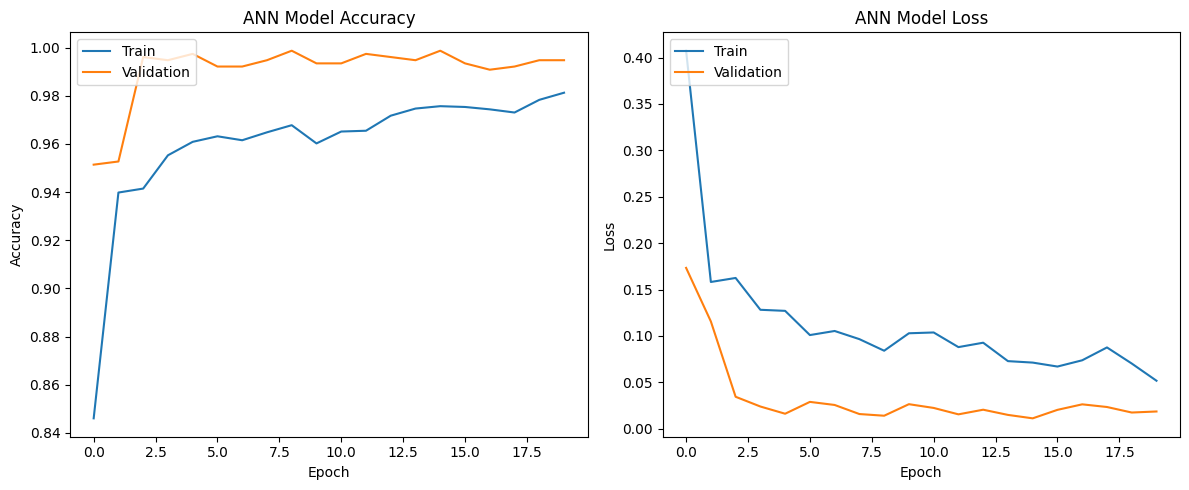

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('ANN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('ANN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

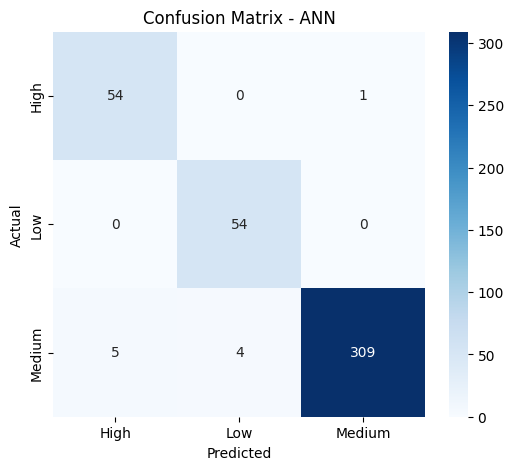

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ANN")
plt.show()

### TabNet

In [ ]:
X_train_tabnet = X_train_selected_scaled.astype(np.float32)
X_test_tabnet  = X_test_selected_scaled.astype(np.float32)

y_train_tabnet = np.array(y_train_resampled)
y_test_tabnet = np.array(y_test)

In [ ]:
tabnet = TabNetClassifier(
    n_d=16, n_a=16,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type="entmax"
)

tabnet.fit(
    X_train_tabnet, y_train_tabnet,
    eval_set=[(X_test_tabnet, y_test_tabnet)],
    eval_name=["valid"],
    eval_metric=["accuracy"],
    max_epochs=200,
    patience=20,
    batch_size=128,
    virtual_batch_size=64,
    num_workers=0,
    drop_last=False
)

y_train_pred_tabnet = tabnet.predict(X_train_tabnet)
y_test_pred_tabnet = tabnet.predict(X_test_tabnet)

train_acc = accuracy_score(y_train_tabnet, y_train_pred_tabnet)
test_acc  = accuracy_score(y_test_tabnet, y_test_pred_tabnet)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.70606 | valid_accuracy: 0.726   |  0:00:04s
epoch 1  | loss: 0.35107 | valid_accuracy: 0.77049 |  0:00:07s
epoch 2  | loss: 0.24948 | valid_accuracy: 0.8267  |  0:00:12s
epoch 3  | loss: 0.21932 | valid_accuracy: 0.8829  |  0:00:21s
epoch 4  | loss: 0.16918 | valid_accuracy: 0.89696 |  0:00:24s
epoch 5  | loss: 0.14209 | valid_accuracy: 0.92506 |  0:00:27s
epoch 6  | loss: 0.11421 | valid_accuracy: 0.93443 |  0:00:29s
epoch 7  | loss: 0.08211 | valid_accuracy: 0.94614 |  0:00:32s
epoch 8  | loss: 0.10629 | valid_accuracy: 0.92974 |  0:00:35s
epoch 9  | loss: 0.10906 | valid_accuracy: 0.94379 |  0:00:37s
epoch 10 | loss: 0.08537 | valid_accuracy: 0.9555  |  0:00:40s
epoch 11 | loss: 0.08269 | valid_accuracy: 0.95082 |  0:00:41s
epoch 12 | loss: 0.08179 | valid_accuracy: 0.95785 |  0:00:43s
epoch 13 | loss: 0.06528 | valid_accuracy: 0.94848 |  0:00:44s
epoch 14 | loss: 0.07878 | valid_accuracy: 0.96019 |  0:00:46s
epoch 15 | loss: 0.05641 | valid_accuracy: 0.95316 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training Accuracy: 0.9910549855301236
Testing Accuracy : 0.9672131147540983


In [ ]:
print(classification_report(y_test_tabnet, y_test_pred_tabnet, target_names=["Low", "Medium", "High"]))

              precision    recall  f1-score   support

         Low       0.90      0.98      0.94        55
      Medium       0.96      0.91      0.93        54
        High       0.98      0.97      0.98       318

    accuracy                           0.97       427
   macro avg       0.95      0.95      0.95       427
weighted avg       0.97      0.97      0.97       427



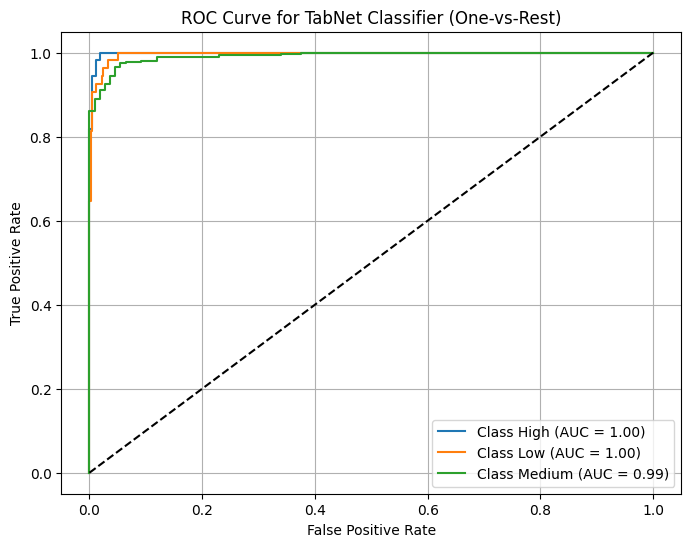

In [ ]:
def plot_multiclass_roc(clf, X_test, y_test, n_classes, class_labels, model_name="Classifier"):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)
    y_score = clf.predict_proba(X_test)

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_score = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name} (One-vs-Rest)')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

class_labels = le.classes_
plot_multiclass_roc(tabnet, X_test_tabnet, y_test_tabnet, n_classes=len(class_labels), class_labels=class_labels, model_name="TabNet Classifier")

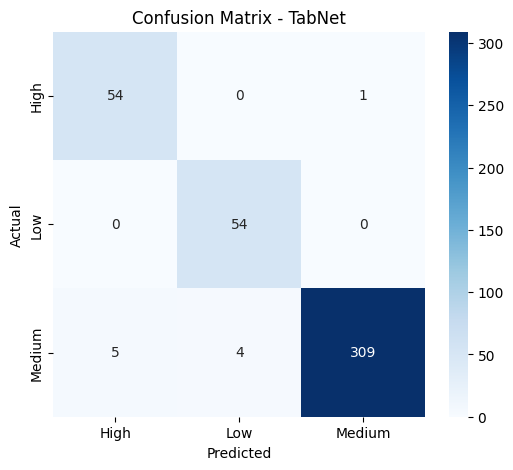

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - TabNet")
plt.show()

### DNN

In [ ]:
num_classes = len(np.unique(y_train_resampled))
y_train_dnn = to_categorical(y_train_resampled, num_classes=num_classes)
y_test_dnn = to_categorical(y_test, num_classes=num_classes)

dnn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_selected_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

dnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = dnn.fit(
    X_train_selected_scaled,
    y_train_dnn,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

train_loss, train_acc = dnn.evaluate(X_train_selected_scaled, y_train_dnn, verbose=0)
test_loss, test_acc = dnn.evaluate(X_test_selected_scaled, y_test_dnn, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8043 - loss: 0.4815 - val_accuracy: 0.9882 - val_loss: 0.1438
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9214 - loss: 0.2232 - val_accuracy: 0.9855 - val_loss: 0.0801
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9372 - loss: 0.1770 - val_accuracy: 0.9882 - val_loss: 0.0482
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9477 - loss: 0.1407 - val_accuracy: 0.9947 - val_loss: 0.0285
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9418 - loss: 0.1546 - val_accuracy: 0.9974 - val_loss: 0.0213
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9536 - loss: 0.1133 - val_accuracy: 0.9947 - val_loss: 0.0390
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9674 - loss: 0.0854 - val_accuracy: 0.9947 - val_loss: 0.0165
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9658 - loss: 0.0990 - val_accuracy: 0.9908 - val_loss: 

In [ ]:
y_pred_prob_dnn = dnn.predict(X_test_selected_scaled)
y_pred_dnn = np.argmax(y_pred_prob_dnn, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dnn, target_names=le.classes_))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification Report:

              precision    recall  f1-score   support

        High       0.92      0.98      0.95        55
         Low       0.93      0.98      0.95        54
      Medium       0.99      0.97      0.98       318

    accuracy                           0.97       427
   macro avg       0.95      0.98      0.96       427
weighted avg       0.98      0.97      0.97       427



14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


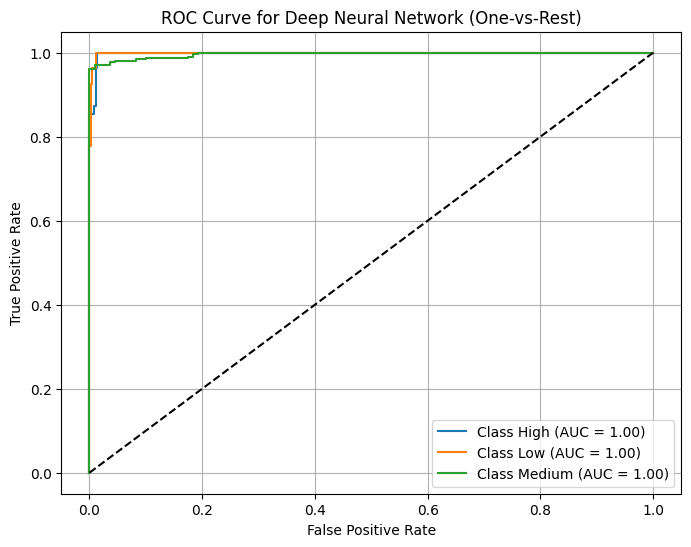

In [ ]:
def plot_multiclass_roc_dnn(model, X_test, y_test, class_labels, model_name="DNN"):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)

    if y_test_bin.ndim == 1:
        y_test_bin = np.column_stack((1 - y_test_bin, y_test_bin))

    y_score = model.predict(X_test)

    plt.figure(figsize=(8, 6))

    for i in range(len(class_labels)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_score = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for {model_name} (One-vs-Rest)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_multiclass_roc_dnn(
    dnn,
    X_test_selected_scaled,
    y_test,
    class_labels=le.classes_,
    model_name="Deep Neural Network"
)

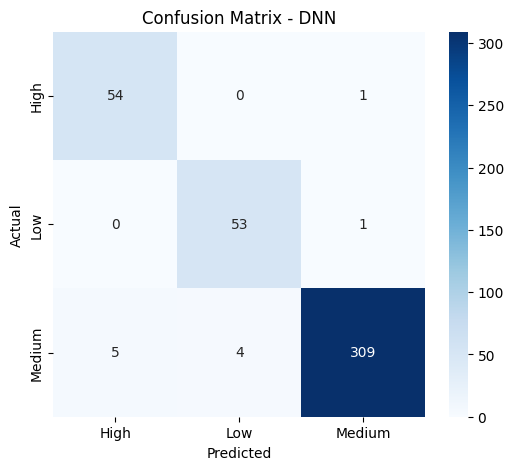

In [ ]:
cm = confusion_matrix(y_test, y_pred_dnn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DNN")
plt.show()

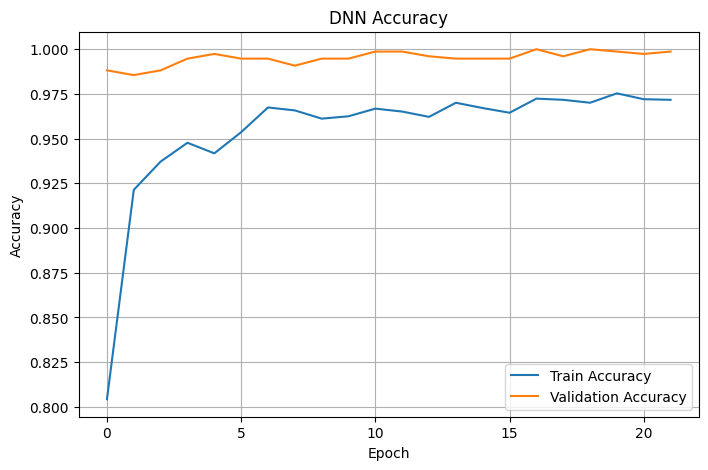

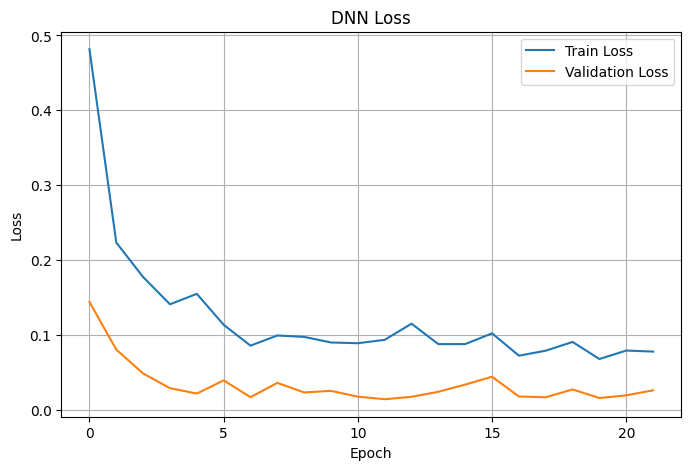

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('DNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('DNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Hybrid model 1

In [ ]:
train_proba_ann = ann.predict(X_train_selected_scaled, verbose=0)
train_proba_lr = log_reg.predict_proba(X_train_selected_scaled)
train_proba_tabnet = tabnet.predict_proba(X_train_selected_scaled)
train_proba_et = et.predict_proba(X_train_selected_scaled)

test_proba_ann = ann.predict(X_test_selected_scaled, verbose=0)
test_proba_lr = log_reg.predict_proba(X_test_selected_scaled)
test_proba_tabnet = tabnet.predict_proba(X_test_selected_scaled)
test_proba_et = et.predict_proba(X_test_selected_scaled)

w_ann = 0.4
w_lr = 0.2
w_tabnet = 0.2
w_et = 0.2

train_weighted_proba = (
    w_ann * train_proba_ann +
    w_lr * train_proba_lr +
    w_tabnet * train_proba_tabnet +
    w_et * train_proba_et
) / (w_ann + w_lr + w_tabnet + w_et)

test_weighted_proba = (
    w_ann * test_proba_ann +
    w_lr * test_proba_lr +
    w_tabnet * test_proba_tabnet +
    w_et * test_proba_et
) / (w_ann + w_lr + w_tabnet + w_et)


y_train_pred_hybrid1 = np.argmax(train_weighted_proba, axis=1)
y_test_pred_hybrid1 = np.argmax(test_weighted_proba, axis=1)

train_acc_hybrid1 = accuracy_score(y_train_resampled, y_train_pred_hybrid1)
test_acc_hybrid1 = accuracy_score(y_test, y_test_pred_hybrid1)

print("Hybrid Model 1 Training Accuracy:", train_acc_hybrid1)
print("Hybrid Model 1 Testing Accuracy :", test_acc_hybrid1)

Hybrid Model 1 Training Accuracy: 0.9973691133912128
Hybrid Model 1 Testing Accuracy : 0.9836065573770492


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_hybrid1, target_names=le.classes_))


Classification Report:

              precision    recall  f1-score   support

        High       0.92      0.98      0.95        55
         Low       0.98      1.00      0.99        54
      Medium       1.00      0.98      0.99       318

    accuracy                           0.98       427
   macro avg       0.96      0.99      0.98       427
weighted avg       0.98      0.98      0.98       427



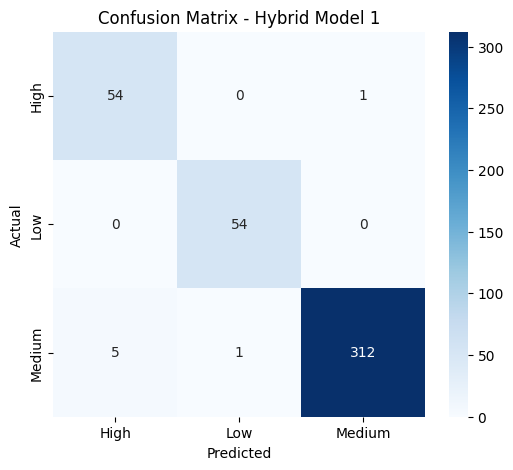

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_hybrid1)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid Model 1")
plt.show()

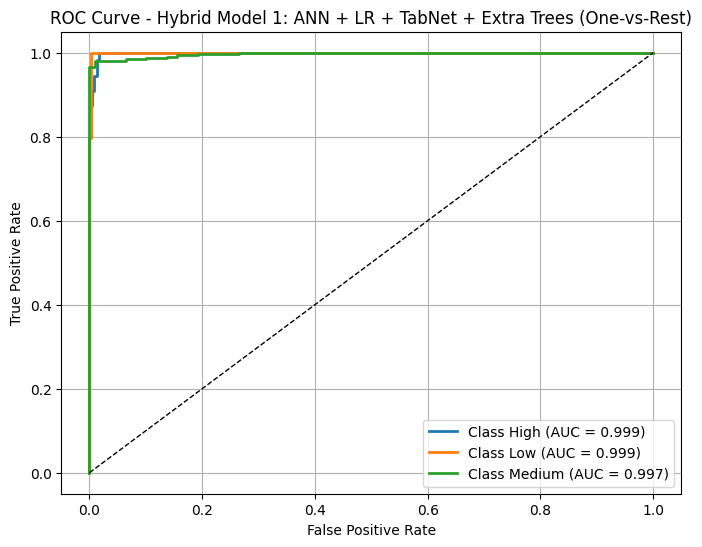


ROC AUC Scores:
High: 0.9985
Low: 0.9995
Medium: 0.9970
Macro Average AUC: 0.9983


In [ ]:
def plot_multiclass_roc_hybrid(y_true, y_proba, class_labels, model_name="Hybrid Model"):
    lb = LabelBinarizer()
    lb.fit(y_true)
    y_true_bin = lb.transform(y_true)

    if y_true_bin.ndim == 1:
        y_true_bin = np.column_stack((1 - y_true_bin, y_true_bin))

    plt.figure(figsize=(8, 6))

    auc_scores = {}

    for i in range(len(class_labels)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        auc_score = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        auc_scores[class_labels[i]] = auc_score

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"Class {class_labels[i]} (AUC = {auc_score:.3f})"
        )

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name} (One-vs-Rest)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

    print("\nROC AUC Scores:")
    for cls, score in auc_scores.items():
        print(f"{cls}: {score:.4f}")

    macro_auc = np.mean(list(auc_scores.values()))
    print("Macro Average AUC:", round(macro_auc, 4))

    return auc_scores, macro_auc


auc_scores_hybrid2, macro_auc_hybrid2 = plot_multiclass_roc_hybrid(
    y_true=y_test,
    y_proba=test_weighted_proba,
    class_labels=le.classes_,
    model_name="Hybrid Model 1: ANN + LR + TabNet + Extra Trees"
)

### Hybrid Model 2

In [ ]:
ann_train = ann.predict(X_train_selected_scaled)
dnn_train = dnn.predict(X_train_selected_scaled)
svm_train = svm.predict_proba(X_train_selected_scaled)
xgb_train = xgb.predict_proba(X_train_selected_scaled)

ann_test = ann.predict(X_test_selected_scaled)
dnn_test = dnn.predict(X_test_selected_scaled)
svm_test = svm.predict_proba(X_test_selected_scaled)
xgb_test = xgb.predict_proba(X_test_selected_scaled)

w_ann = 0.3
w_dnn = 0.7
w_svm = 0.0
w_xgb = 0.0

train_probs_hybrid2 = (
    w_ann * ann_train +
    w_dnn * dnn_train +
    w_svm * svm_train +
    w_xgb * xgb_train
)

test_probs_hybrid2 = (
    w_ann * ann_test +
    w_dnn * dnn_test +
    w_svm * svm_test +
    w_xgb * xgb_test
)

y_train_pred_hybrid2 = np.argmax(train_probs_hybrid2, axis=1)
y_test_pred_hybrid2 = np.argmax(test_probs_hybrid2, axis=1)

train_acc_hybrid2 = accuracy_score(y_train_resampled, y_train_pred_hybrid2)
test_acc_hybrid2 = accuracy_score(y_test, y_test_pred_hybrid2)

print("Hybrid Model 2 Training Accuracy:", train_acc_hybrid2)
print("Hybrid Model 2 Testing Accuracy :", test_acc_hybrid2)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Hybrid Model 2 Training Accuracy: 0.9950013154433044
Hybrid Model 2 Testing Accuracy : 0.9789227166276346


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_hybrid2, target_names=le.classes_))


Classification Report:

              precision    recall  f1-score   support

        High       0.92      0.98      0.95        55
         Low       0.95      1.00      0.97        54
      Medium       1.00      0.97      0.99       318

    accuracy                           0.98       427
   macro avg       0.95      0.99      0.97       427
weighted avg       0.98      0.98      0.98       427



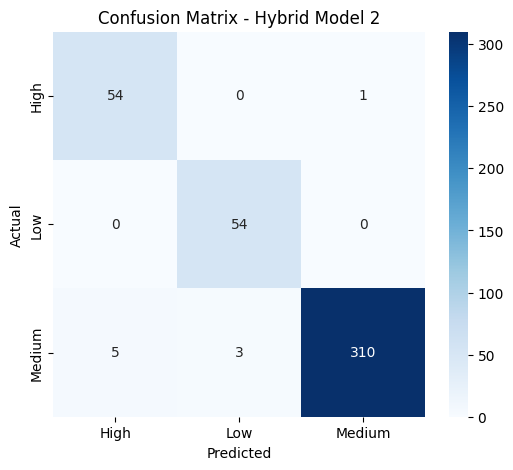

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_hybrid2)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid Model 2")
plt.show()

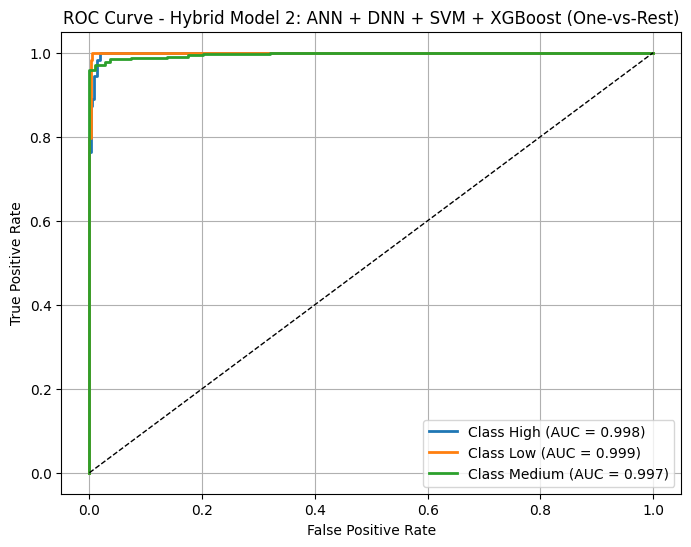


ROC AUC Scores:
High: 0.9983
Low: 0.9994
Medium: 0.9966
Macro Average AUC: 0.9981


In [ ]:
def plot_multiclass_roc_hybrid(y_true, y_proba, class_labels, model_name="Hybrid Model"):
    lb = LabelBinarizer()
    lb.fit(y_true)
    y_true_bin = lb.transform(y_true)

    if y_true_bin.ndim == 1:
        y_true_bin = np.column_stack((1 - y_true_bin, y_true_bin))

    plt.figure(figsize=(8, 6))

    auc_scores = {}

    for i in range(len(class_labels)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        auc_score = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        auc_scores[class_labels[i]] = auc_score

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"Class {class_labels[i]} (AUC = {auc_score:.3f})"
        )

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name} (One-vs-Rest)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

    print("\nROC AUC Scores:")
    for cls, score in auc_scores.items():
        print(f"{cls}: {score:.4f}")

    macro_auc = np.mean(list(auc_scores.values()))
    print("Macro Average AUC:", round(macro_auc, 4))

    return auc_scores, macro_auc


auc_scores_hybrid2, macro_auc_hybrid2 = plot_multiclass_roc_hybrid(
    y_true=y_test,
    y_proba=test_weighted_proba,
    class_labels=le.classes_,
    model_name="Hybrid Model 2: ANN + DNN + SVM + XGBoost"
)

### Permutation Importance

In [ ]:
lifestyle_features = [
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity",
    "Screen_Time",
    "Stress_Level",
    "Caffeine_Intake",
    "Multitasking",
    "Long_Form_Content"
]

X_life = df[lifestyle_features]
y_life = df["Attention_Class"]

In [ ]:
X_train_life, X_test_life, y_train_life, y_test_life = train_test_split(
    X_life,
    y_life,
    test_size=0.2,
    random_state=42,
    stratify=y_life
)

In [ ]:
extra_trees_life = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42
)

extra_trees_life.fit(X_train_life, y_train_life)

ExtraTreesClassifier(n_estimators=500, random_state=42)

In [ ]:
perm = permutation_importance(
    extra_trees_life,
    X_test_life,
    y_test_life,
    n_repeats=30,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": lifestyle_features,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

print(perm_df)

             Feature  Importance
3        Screen_Time    0.065183
2  Physical_Activity    0.048478
0        Sleep_Hours    0.033177
7  Long_Form_Content    0.032553
1      Sleep_Quality    0.028025
6       Multitasking    0.017799
4       Stress_Level    0.017096
5    Caffeine_Intake    0.007572


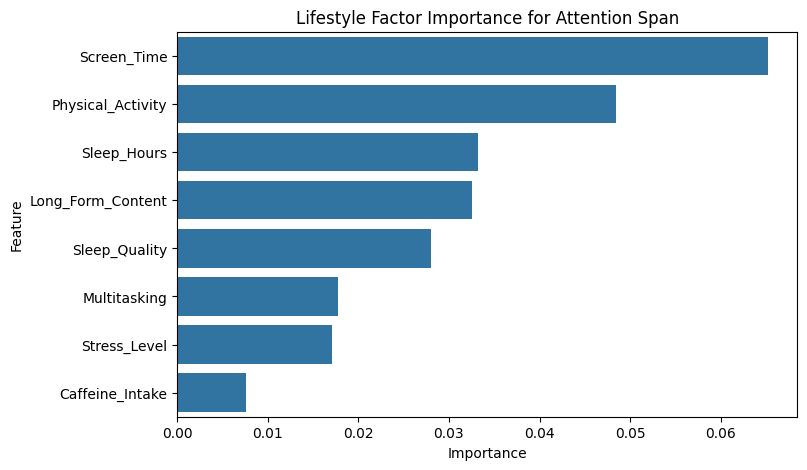

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=perm_df,
    x="Importance",
    y="Feature"
)

plt.title("Lifestyle Factor Importance for Attention Span")
plt.show()

In [ ]:
xgb_life = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_life.fit(X_train_life, y_train_life)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


Permutation Importance - XGBoost

             Feature  Importance
3        Screen_Time    0.054411
2  Physical_Activity    0.031382
1      Sleep_Quality    0.027869
0        Sleep_Hours    0.020921
7  Long_Form_Content    0.016003
4       Stress_Level    0.013661
6       Multitasking    0.012178
5    Caffeine_Intake   -0.005621


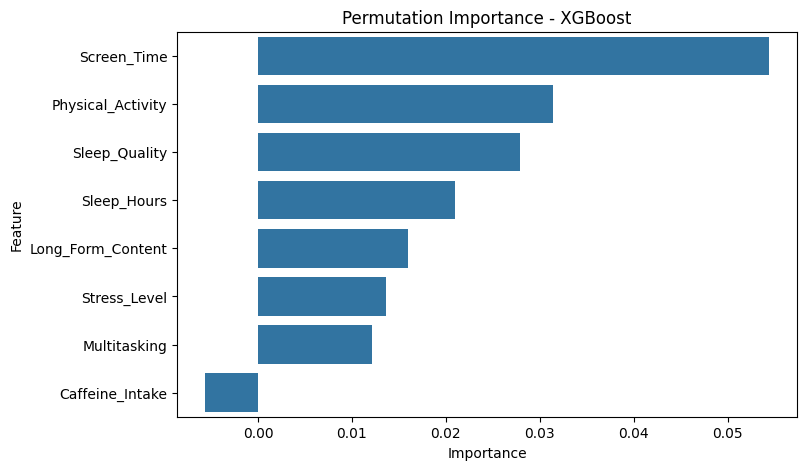

In [ ]:
perm_xgb = permutation_importance(
    xgb_life,
    X_test_life,
    y_test_life,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

perm_xgb_df = pd.DataFrame({
    "Feature": lifestyle_features,
    "Importance": perm_xgb.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nPermutation Importance - XGBoost\n")
print(perm_xgb_df)

plt.figure(figsize=(8,5))
sns.barplot(data=perm_xgb_df, x="Importance", y="Feature")
plt.title("Permutation Importance - XGBoost")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Permutation Importance - Logistic Regression

             Feature  Importance
3        Screen_Time    0.055972
2  Physical_Activity    0.031460
7  Long_Form_Content    0.030991
0        Sleep_Hours    0.025137
1      Sleep_Quality    0.024980
6       Multitasking    0.009602
4       Stress_Level    0.007182
5    Caffeine_Intake    0.002498


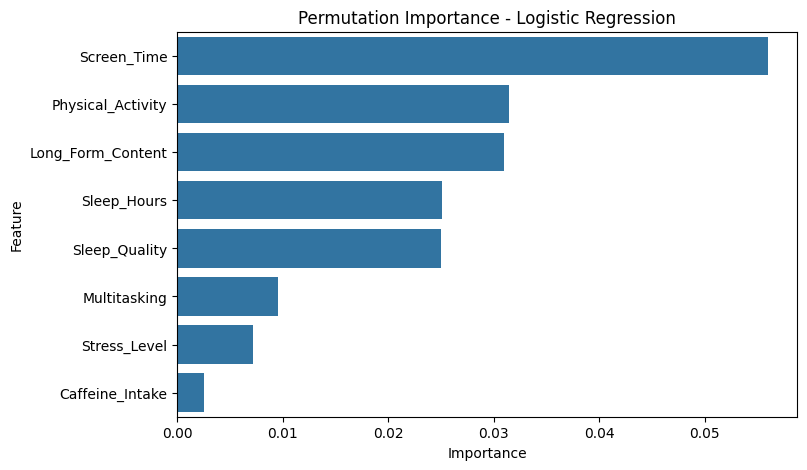

In [ ]:
log_reg_life = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=42
)

log_reg_life.fit(X_train_life, y_train_life)

perm_lr = permutation_importance(
    log_reg_life,
    X_test_life,
    y_test_life,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

perm_lr_df = pd.DataFrame({
    "Feature": lifestyle_features,
    "Importance": perm_lr.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nPermutation Importance - Logistic Regression\n")
print(perm_lr_df)

plt.figure(figsize=(8,5))
sns.barplot(data=perm_lr_df, x="Importance", y="Feature")
plt.title("Permutation Importance - Logistic Regression")
plt.show()

### Feature Importance

In [ ]:
lifestyle_behavioral_cols = [
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity",
    "Screen_Time",
    "Stress_Level",
    "Caffeine_Intake",
    "Multitasking",
    "Long_Form_Content"
]

Feature Importance - Extra Trees

             Feature  Importance
3        Screen_Time    0.162655
2  Physical_Activity    0.138867
1      Sleep_Quality    0.133689
7  Long_Form_Content    0.131781
4       Stress_Level    0.122845
0        Sleep_Hours    0.120843
6       Multitasking    0.097308
5    Caffeine_Intake    0.092011


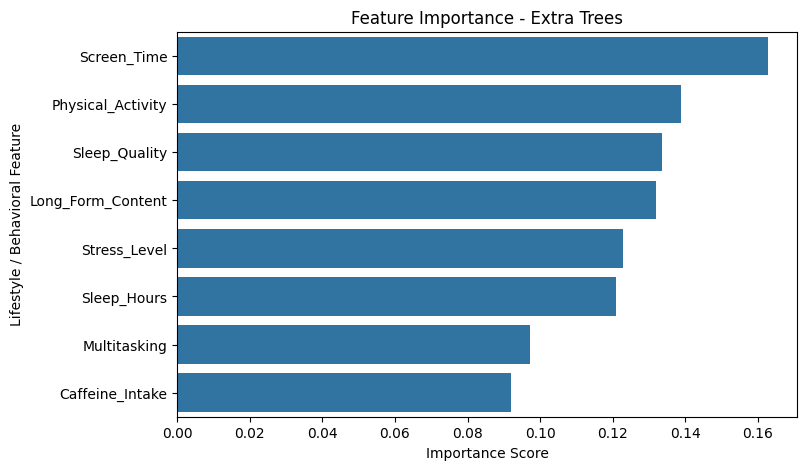

In [ ]:
et_importance_df = pd.DataFrame({
    "Feature": lifestyle_behavioral_cols,
    "Importance": extra_trees_life.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Feature Importance - Extra Trees\n")
print(et_importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=et_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Extra Trees")
plt.xlabel("Importance Score")
plt.ylabel("Lifestyle / Behavioral Feature")
plt.show()

Feature Importance - XGBoost

             Feature  Importance
3        Screen_Time    0.219717
2  Physical_Activity    0.198133
0        Sleep_Hours    0.146134
1      Sleep_Quality    0.122148
7  Long_Form_Content    0.117150
4       Stress_Level    0.074047
6       Multitasking    0.063174
5    Caffeine_Intake    0.059497


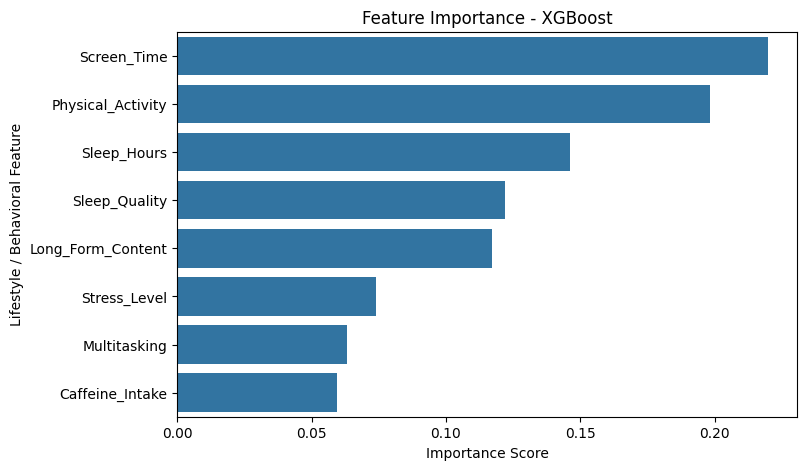

In [ ]:
xgb_importance_df = pd.DataFrame({
    "Feature": lifestyle_behavioral_cols,
    "Importance": xgb_life.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Feature Importance - XGBoost\n")
print(xgb_importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=xgb_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Lifestyle / Behavioral Feature")
plt.show()

Feature Importance - Logistic Regression

             Feature  Importance
3        Screen_Time    0.707819
7  Long_Form_Content    0.640275
0        Sleep_Hours    0.491602
2  Physical_Activity    0.469304
1      Sleep_Quality    0.403794
4       Stress_Level    0.254348
6       Multitasking    0.146270
5    Caffeine_Intake    0.087994


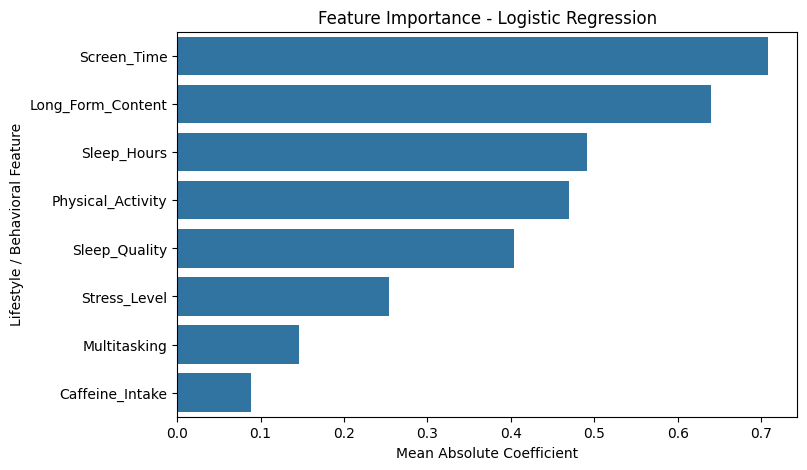

In [ ]:
lr_importance = np.mean(np.abs(log_reg_life.coef_), axis=0)

lr_importance_df = pd.DataFrame({
    "Feature": lifestyle_behavioral_cols,
    "Importance": lr_importance
}).sort_values(by="Importance", ascending=False)

print("Feature Importance - Logistic Regression\n")
print(lr_importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=lr_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Lifestyle / Behavioral Feature")
plt.show()

### Class-wise Logistic Regression Coefficients

In [ ]:
coef_df = pd.DataFrame(
    log_reg_life.coef_.T,
    index=lifestyle_behavioral_cols,
    columns=le.classes_
)

print("Class-wise Logistic Regression Coefficients\n")
print(coef_df)

Class-wise Logistic Regression Coefficients

                       High       Low    Medium
Sleep_Hours        0.662020 -0.737403  0.075382
Sleep_Quality      0.605691 -0.529133 -0.076558
Physical_Activity  0.703956 -0.512449 -0.191507
Screen_Time       -1.029551  1.061729 -0.032178
Stress_Level      -0.243112  0.381521 -0.138409
Caffeine_Intake    0.131990 -0.130804 -0.001186
Multitasking      -0.192143 -0.027262  0.219405
Long_Form_Content  0.903169 -0.960413  0.057244


### Average Absolute Coefficient Importance

In [ ]:
importance = np.mean(np.abs(log_reg_life.coef_), axis=0)

importance_df = pd.DataFrame({
    "Feature": lifestyle_behavioral_cols,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)

             Feature  Importance
3        Screen_Time    0.707819
7  Long_Form_Content    0.640275
0        Sleep_Hours    0.491602
2  Physical_Activity    0.469304
1      Sleep_Quality    0.403794
4       Stress_Level    0.254348
6       Multitasking    0.146270
5    Caffeine_Intake    0.087994


### Combined Feature Impotance

In [ ]:
combined_feature_importance = pd.DataFrame({
    "Feature": lifestyle_behavioral_cols,
    "ExtraTrees": et_importance_df.set_index("Feature").loc[lifestyle_behavioral_cols, "Importance"].values,
    "XGBoost": xgb_importance_df.set_index("Feature").loc[lifestyle_behavioral_cols, "Importance"].values,
    "LogisticRegression": lr_importance_df.set_index("Feature").loc[lifestyle_behavioral_cols, "Importance"].values
})

combined_feature_importance["Average_Importance"] = combined_feature_importance[
    ["ExtraTrees", "XGBoost", "LogisticRegression"]
].mean(axis=1)

combined_feature_importance = combined_feature_importance.sort_values(
    by="Average_Importance",
    ascending=False
)

print("Combined Feature Importance Across Models\n")
print(combined_feature_importance)

Combined Feature Importance Across Models

             Feature  ExtraTrees   XGBoost  LogisticRegression  \
3        Screen_Time    0.162655  0.219717            0.707819   
7  Long_Form_Content    0.131781  0.117150            0.640275   
2  Physical_Activity    0.138867  0.198133            0.469304   
0        Sleep_Hours    0.120843  0.146134            0.491602   
1      Sleep_Quality    0.133689  0.122148            0.403794   
4       Stress_Level    0.122845  0.074047            0.254348   
6       Multitasking    0.097308  0.063174            0.146270   
5    Caffeine_Intake    0.092011  0.059497            0.087994   

   Average_Importance  
3            0.363397  
7            0.296402  
2            0.268768  
0            0.252859  
1            0.219877  
4            0.150413  
6            0.102251  
5            0.079834  


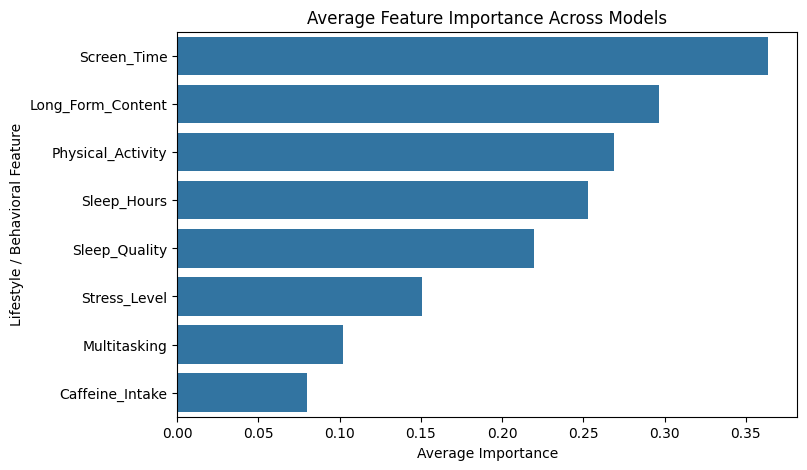

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=combined_feature_importance,
    x="Average_Importance",
    y="Feature"
)
plt.title("Average Feature Importance Across Models")
plt.xlabel("Average Importance")
plt.ylabel("Lifestyle / Behavioral Feature")
plt.show()

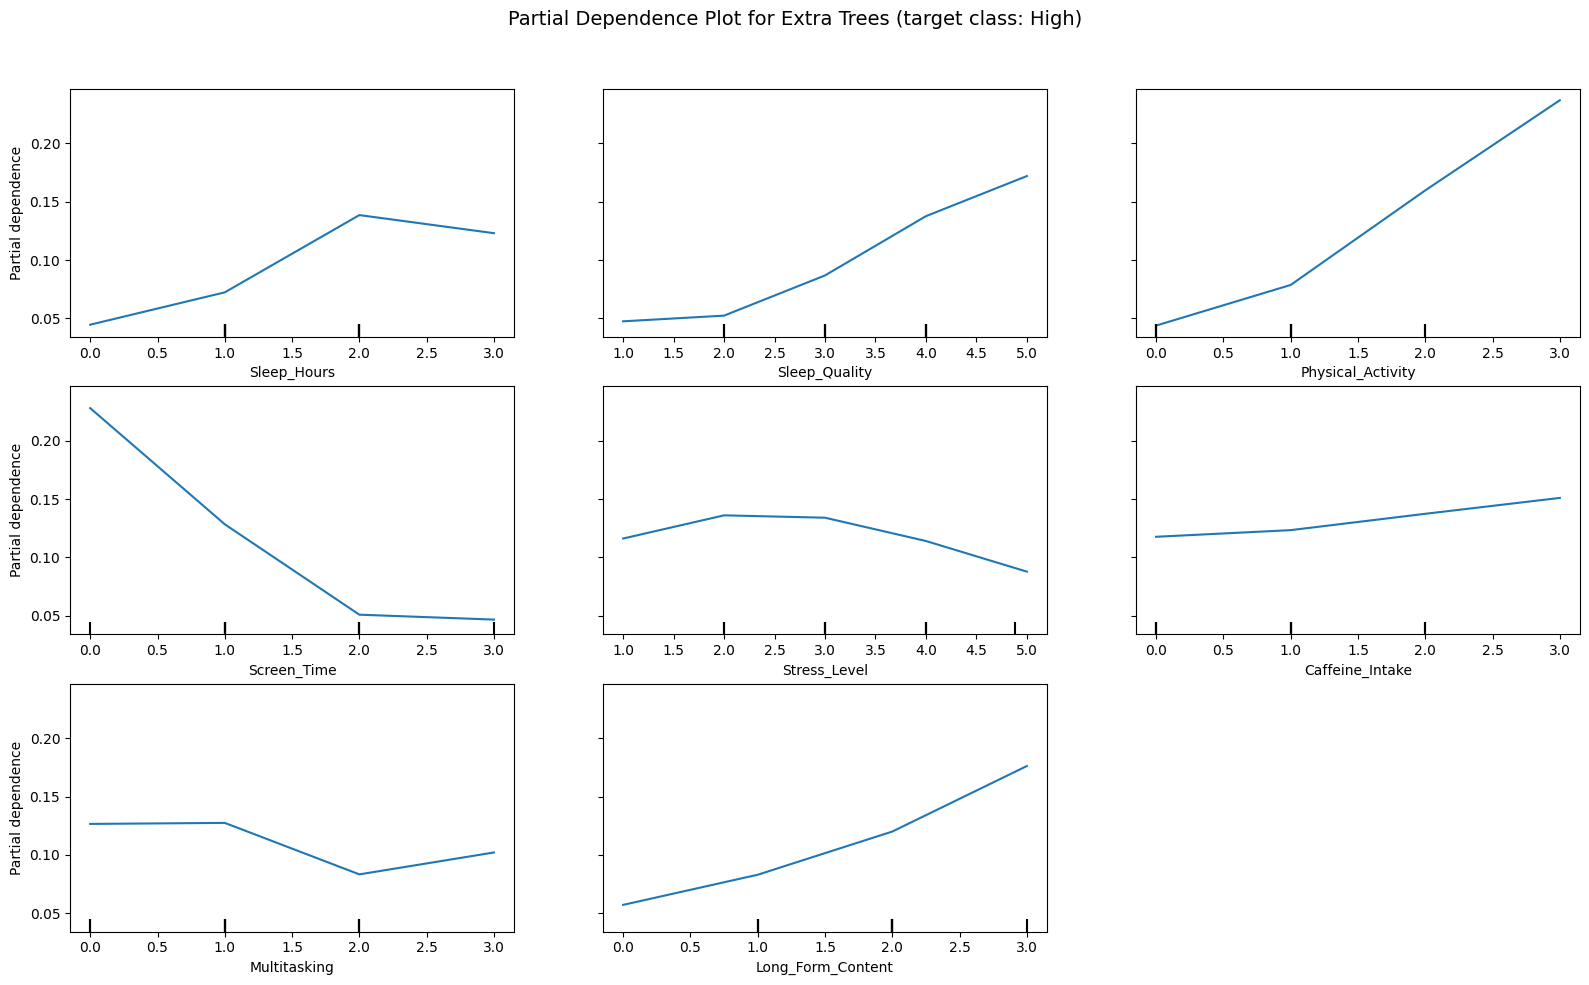

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features_to_analyze = [
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity",
    "Screen_Time",
    "Stress_Level",
    "Caffeine_Intake",
    "Multitasking",
    "Long_Form_Content"
]

fig, ax = plt.subplots(figsize=(16, 10))

PartialDependenceDisplay.from_estimator(
    extra_trees_life,
    X_test_life,
    features_to_analyze,
    target=target_class_index,
    feature_names=X_test_life.columns.tolist(),
    ax=ax
)

plt.suptitle(
    f"Partial Dependence Plot for Extra Trees (target class: {le.classes_[target_class_index]})",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

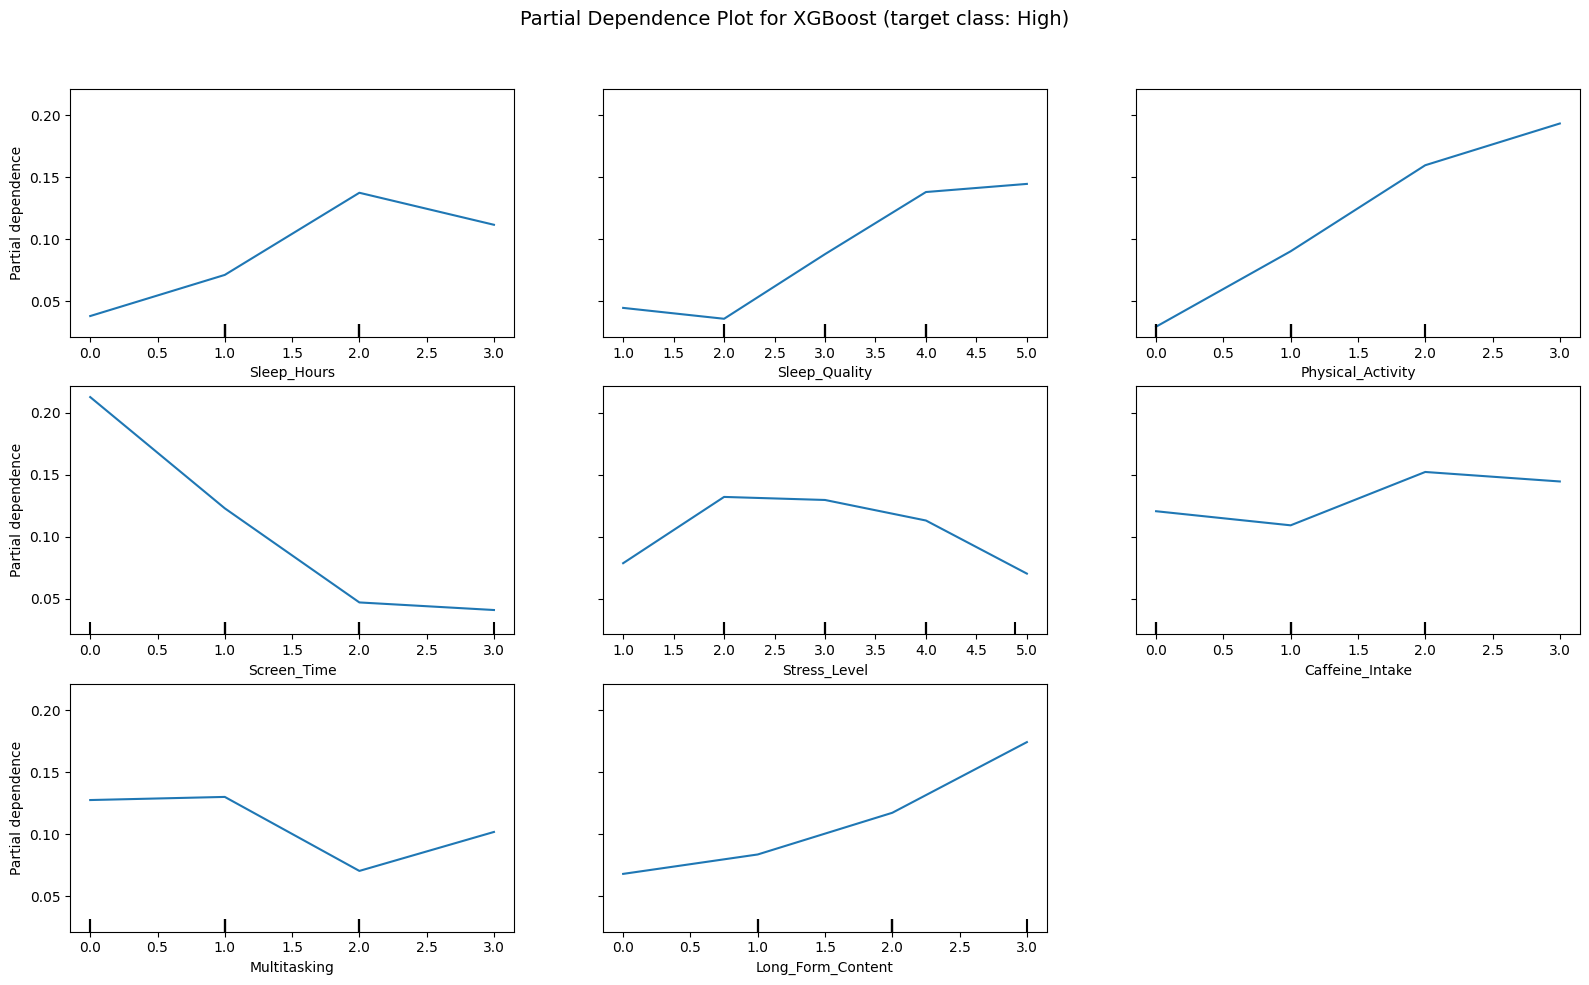

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features_to_analyze = [
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity",
    "Screen_Time",
    "Stress_Level",
    "Caffeine_Intake",
    "Multitasking",
    "Long_Form_Content"
]

fig, ax = plt.subplots(figsize=(16, 10))

PartialDependenceDisplay.from_estimator(
    xgb_life,
    X_test_life,
    features_to_analyze,
    target=target_class_index,
    feature_names=X_test_life.columns.tolist(),
    ax=ax
)

plt.suptitle(
    f"Partial Dependence Plot for XGBoost (target class: {le.classes_[target_class_index]})",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

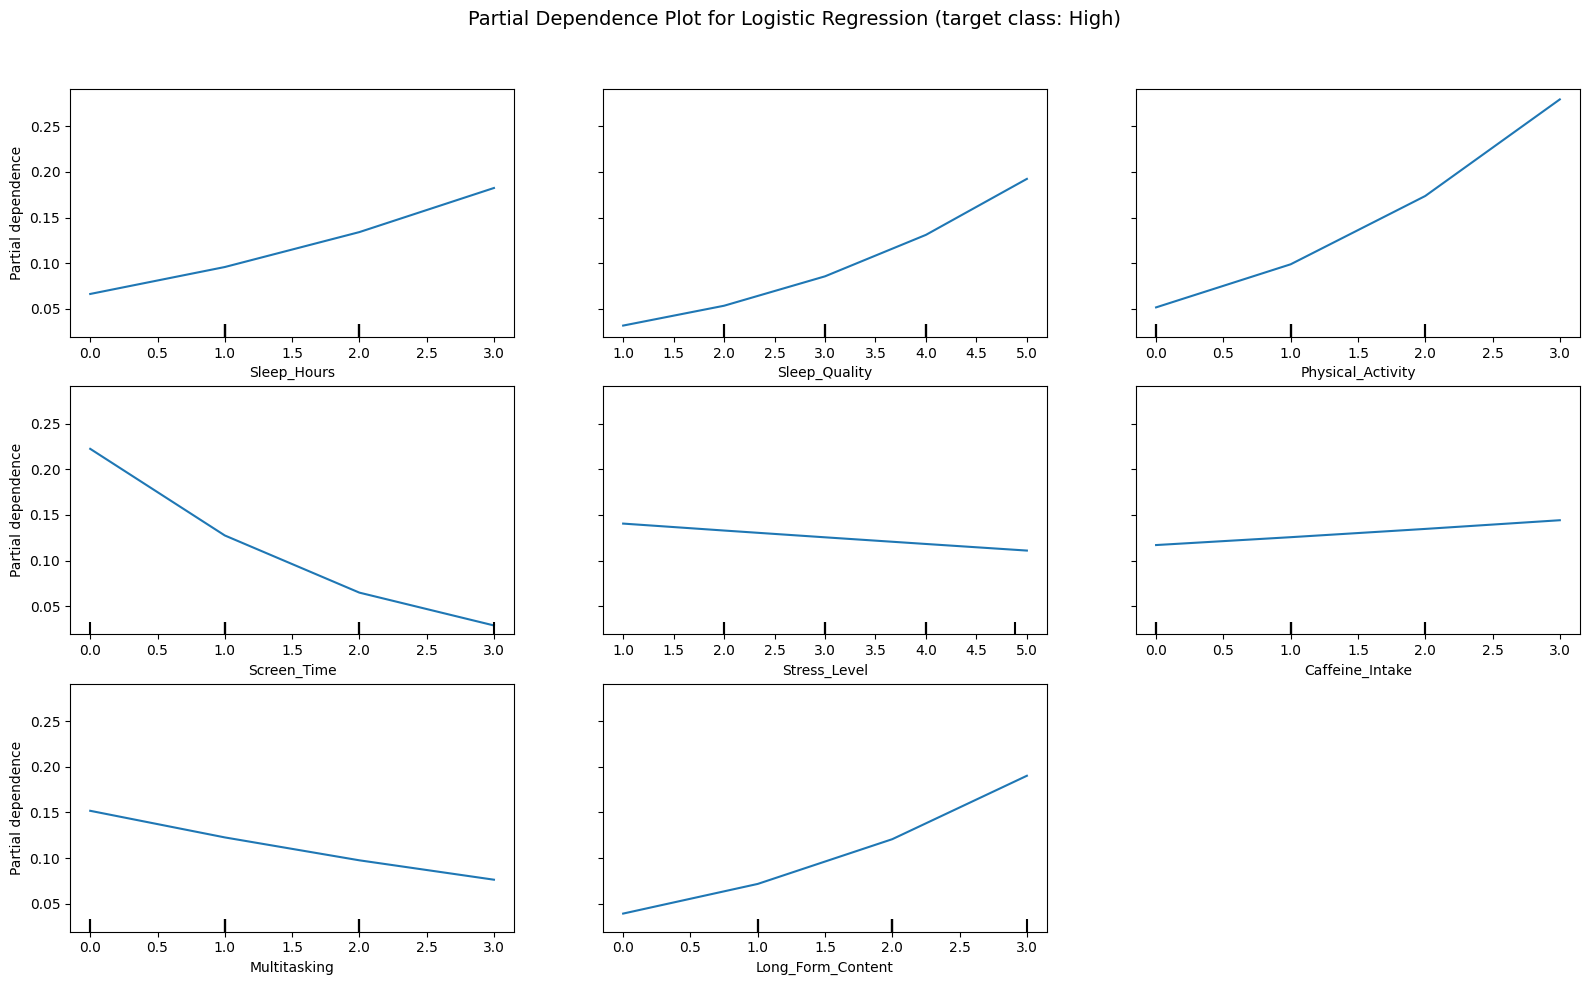

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features_to_analyze = [
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity",
    "Screen_Time",
    "Stress_Level",
    "Caffeine_Intake",
    "Multitasking",
    "Long_Form_Content"
]

fig, ax = plt.subplots(figsize=(16, 10))

PartialDependenceDisplay.from_estimator(
    log_reg_life,
    X_test_life,
    features_to_analyze,
    target=target_class_index,
    feature_names=X_test_life.columns.tolist(),
    ax=ax
)

plt.suptitle(
    f"Partial Dependence Plot for Logistic Regression (target class: {le.classes_[target_class_index]})",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

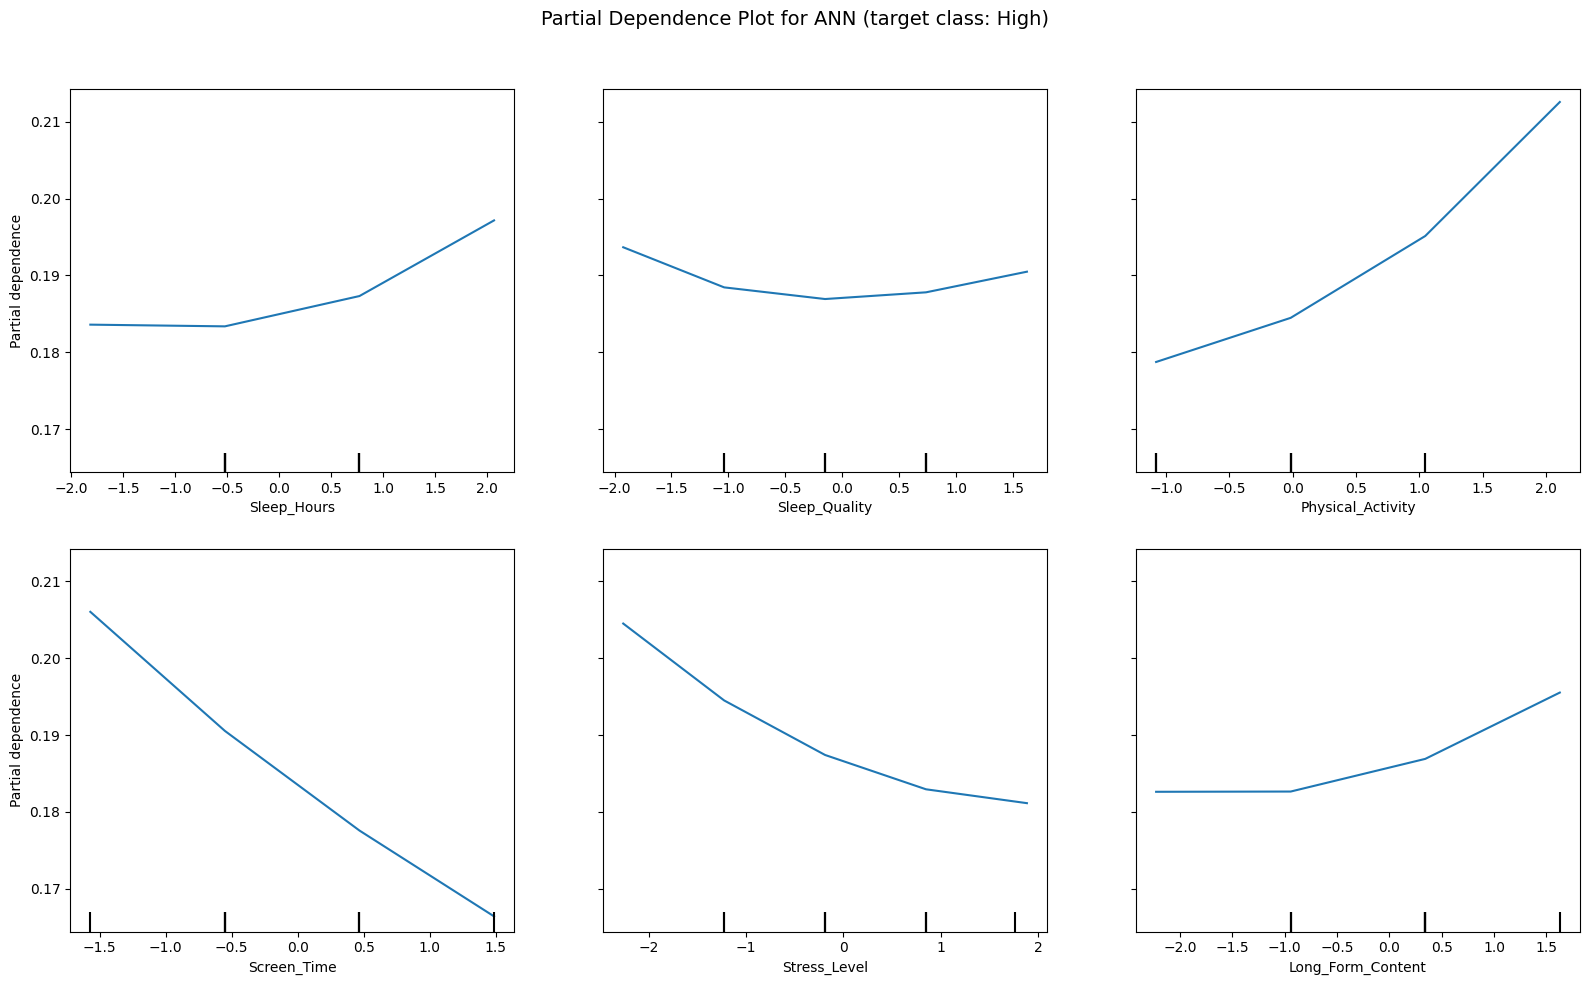

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import numpy as np # Import numpy

features_to_analyze = [
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity",
    "Screen_Time",
    "Stress_Level",
    "Caffeine_Intake",
    "Multitasking",
    "Long_Form_Content"
]

# Get the names of the features selected by SelectKBest
selected_feature_names = X.columns[selector.get_support()]

# Filter features_to_analyze to only include those present in the selected features
ann_features_for_pdp = [f for f in features_to_analyze if f in selected_feature_names]

# Map these feature names to their indices in the X_test_selected_scaled array
feature_indices_for_pdp = [selected_feature_names.get_loc(f) for f in ann_features_for_pdp]

fig, ax = plt.subplots(figsize=(16, 10))

# Redefine the ANN model
ann = keras.Sequential([
    layers.Input(shape=(X_train_selected_scaled.shape[1],)),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Manually set the classes_ attribute for sklearn compatibility
ann.classes_ = np.unique(y_train_resampled) # Use unique labels from training data

# Use y_train_resampled directly as sparse_categorical_crossentropy expects integer labels
ann.fit(
    X_train_selected_scaled,
    y_train_resampled,
    epochs=1,
    batch_size=32,
    verbose=0
)

# Create a wrapper for the Keras model to be compatible with PartialDependenceDisplay
class KerasClassifierWrapper:
    def __init__(self, keras_model, classes_):
        self.keras_model = keras_model
        self.classes_ = classes_
        self._estimator_type = 'classifier'

    def fit(self, X, y=None): # Added a dummy fit method
        return self

    def predict_proba(self, X):
        # Keras model's predict method outputs probabilities for softmax output
        return self.keras_model.predict(X, verbose=0)

# Instantiate the wrapper with your trained Keras model and its classes
ann_wrapped = KerasClassifierWrapper(ann, ann.classes_)

# Generate PDP for ANN model using the relevant subset of selected features
PartialDependenceDisplay.from_estimator(
    ann_wrapped, # Use the wrapped model
    X_test_selected_scaled,
    features=feature_indices_for_pdp,
    target=target_class_index,
    feature_names=ann_features_for_pdp,
    ax=ax
)

plt.suptitle(
    f"Partial Dependence Plot for ANN (target class: {le.classes_[target_class_index]})",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()